# GLM Analysis — spatial embeddings × health outcomes

Same four-question design as `analyses_transformed.ipynb` but with four
interpretable model families instead of LightGBM:

| Key | Model | Speed |
|-----|-------|-------|
| `lasso` | L1-penalised linear (α = 0.05) | fast |
| `binomial_glm` | Binomial GLM, logit link | moderate |
| `beta` | Beta regression (boundary-corrected) | slow |
| `nb` | Negative Binomial GLM, log link | moderate |

**R² scale:** identical to the original notebook — logit-scale for proportion
targets, log1p-scale for dollar/count targets — enabling direct comparison.

**Feature scaling:** `StandardScaler` is fitted on training data within each
fold and applied to validation/test data.  Required for Lasso (regularisation
is scale-sensitive); also improves GLM convergence.

**Outputs → `outputs/other_models/`** — one CSV per model per question, cached
so subsequent runs are instant.


In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import polars as pl
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso, LassoCV, ElasticNet
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.special import logit as scipy_logit, expit
import matplotlib
import matplotlib.pyplot as plt

# Beta regression requires statsmodels >= 0.13
try:
    from statsmodels.othermod.betareg import BetaModel
    HAS_BETA = True
except ImportError:
    HAS_BETA = False
    print("WARNING: BetaModel not found (statsmodels >= 0.13 required). "
          "Beta regression will be skipped.")


In [2]:
DATA_DIR    = Path("../../data")
OUTPUTS_DIR = Path("../../outputs/other_models_cont")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# When True each model cell loads cached CSV instead of refitting.
# Set to False to rerun from scratch.
USE_CACHED = True

STAT_SUFFIXES = ["MEAN", "MEDIAN", "MINIMUM", "MAXIMUM", "STD"]
EMB_COLS      = [f"A{i:02d}_{s}" for i in range(64) for s in STAT_SUFFIXES]  # 320 cols
FEATURE_COLS  = EMB_COLS + ["ALAND", "AWATER"]  # 322 features

# ── Model registry ─────────────────────────────────────────────────────────────
# Flip a value to False to skip that model (Binomial GLM / Beta / NB are slow
# on first run; Lasso is fast and a good first check).
ACTIVE_MODELS = {
    "lasso":        True,          # after lasso decided best and found best lasso alpha
    #"binomial_glm": True,
    #"beta":         HAS_BETA,
    #"nb":           True,
}
MODEL_LABELS = {
    "lasso":        "Lasso (L1, α=0.05)",
    "binomial_glm": "Binomial GLM",
    "beta":         "Beta Regression",
    "nb":           "Neg. Binomial",
}
MODEL_COLORS = {
    "lasso":        "#2196F3",
    "binomial_glm": "#E53935",
    "beta":         "#43A047",
    "nb":           "#FF9800",
}

# Conservative L1 penalty: eliminates noise without being too aggressive.
# Chosen to match roughly 1–5% regularisation relative to standardised coefficients.
LASSO_ALPHA    = 0.01   # from LassoCV 
EPS            = 1e-4   # logit boundary clip
PSEUDO_COUNT_N = 1_000  # proportion → NB pseudo-count denominator (y_prop × 1000)


In [9]:
acs_path = DATA_DIR / "acs.csv"

if not acs_path.exists():
    print("data/acs.csv not found — running get_data.py (~5 min for all 50 states)...")
    result = subprocess.run(
        [sys.executable, "get_data.py"],
        capture_output=True, text=True,
    )
    print(result.stdout[-3_000:] if len(result.stdout) > 3_000 else result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
else:
    print(f"✓  ACS data present: {acs_path}")


✓  ACS data present: ../../data/acs.csv


In [10]:
emb_tract = (
    pl.read_csv(DATA_DIR / "alphaearth_embeddings.csv", infer_schema_length=10_000)
    .filter((pl.col("year") == 2022) & pl.col("A00_MAXIMUM").is_not_null())
    .with_columns(
        pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips")
    )
    .select(["tract_fips"] + EMB_COLS + ["ALAND", "AWATER"])
)
print(f"Tracts with 2022 embeddings: {len(emb_tract):,}")
print(f"Feature columns: {len(FEATURE_COLS)}  ({len(EMB_COLS)} embedding stats + 2 area)")


Tracts with 2022 embeddings: 85,528
Feature columns: 322  (320 embedding stats + 2 area)


In [11]:
_places_raw = pl.read_csv(
    DATA_DIR / "PLACES__Local_Data_for_Better_Health__Census_Tract_Data__2025_release.csv",
    infer_schema_length=10_000,
)
PLACES_LABELS: dict[str, str] = dict(
    _places_raw.select(["MeasureId", "Short_Question_Text"]).unique().iter_rows()
)
_places_long = (
    _places_raw
    .filter(pl.col("Year").is_in([2022, 2023]))
    .select(["Year", "LocationID", "MeasureId", "Data_Value"])
    .with_columns(pl.col("LocationID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("LocationID")
)
_measures_2022     = set(_places_long.filter(pl.col("Year") == 2022)["MeasureId"].unique().to_list())
_measures_2023_only = (
    set(_places_long.filter(pl.col("Year") == 2023)["MeasureId"].unique().to_list())
    - _measures_2022
)
places_wide = (
    pl.concat([
        _places_long.filter((pl.col("Year") == 2022) & pl.col("MeasureId").is_in(_measures_2022)),
        _places_long.filter((pl.col("Year") == 2023) & pl.col("MeasureId").is_in(_measures_2023_only)),
    ])
    .drop("Year")
    .pivot(on="MeasureId", index="tract_fips", values="Data_Value")
)
PLACES_MEASURES = sorted([c for c in places_wide.columns if c != "tract_fips"])
print(f"PLACES: {len(places_wide):,} tracts × {len(PLACES_MEASURES)} measures")


PLACES: 83,522 tracts × 40 measures


In [12]:
ACS_RENAME = {
    "B17021_001E": "pov_universe", "B17021_002E": "pov_below_related_children",
    "B17021_003E": "pov_below_other", "S1701_C01_001E": "pov_determination_universe",
    "S1701_C01_040E": "pct_below_150pct_poverty", "S1701_C02_001E": "pct_below_100pct_poverty",
    "B19001_002E": "hh_income_lt10k", "B19001_017E": "hh_income_ge200k",
    "B19113_001E": "median_family_income", "B19301_001E": "per_capita_income",
    "B23025_003E": "labor_force", "B23025_005E": "unemployed",
    "DP03_0009PE": "unemployment_pct", "S2301_C04_001E": "not_in_labor_force_pct",
    "B15003_001E": "educ_universe", "B15003_002E": "educ_no_schooling",
    "B15003_003E": "educ_nursery", "B15003_004E": "educ_kindergarten",
    "B15003_005E": "educ_grade1", "B15003_006E": "educ_grade2",
    "B15003_007E": "educ_grade3", "B15003_008E": "educ_grade4",
    "B15003_009E": "educ_grade5", "B15003_010E": "educ_grade6",
    "B15003_011E": "educ_grade7", "B15003_012E": "educ_grade8",
    "B15003_013E": "educ_grade9", "B15003_014E": "educ_grade10",
    "B15003_015E": "educ_grade11", "B15003_016E": "educ_grade12_no_diploma",
    "B15003_017E": "educ_hs_diploma", "B15003_018E": "educ_ged",
    "B15003_019E": "educ_some_college_lt1yr", "B15003_020E": "educ_some_college_ge1yr",
    "B15003_021E": "educ_associates", "B15003_022E": "educ_bachelors",
    "B15003_023E": "educ_masters", "B15003_024E": "educ_professional_degree",
    "B15003_025E": "educ_doctorate", "S0601_C01_001E": "pop_25plus",
    "S0601_C01_033E": "no_hs_diploma_pct",
    "B16005_001E": "lang_universe",
    "B16005_007E": "lep_spanish_native_not_well", "B16005_008E": "lep_spanish_native_not_at_all",
    "B16005_012E": "lep_spanish_foreign_not_well", "B16005_013E": "lep_spanish_foreign_not_at_all",
    "B16005_017E": "lep_indo_euro_native_not_well", "B16005_018E": "lep_indo_euro_native_not_at_all",
    "B16005_022E": "lep_indo_euro_foreign_not_well", "B16005_023E": "lep_indo_euro_foreign_not_at_all",
    "B16005_029E": "lep_asian_pac_native_not_well", "B16005_030E": "lep_asian_pac_native_not_at_all",
    "B16005_034E": "lep_asian_pac_foreign_not_well", "B16005_035E": "lep_asian_pac_foreign_not_at_all",
    "B16005_039E": "lep_other_native_not_well", "B16005_040E": "lep_other_native_not_at_all",
    "B16005_044E": "lep_other_foreign_not_well", "B16005_045E": "lep_other_foreign_not_at_all",
    "C24010_001E": "occ_universe",
    "C24010_019E": "occ_male_mgmt_business_science_arts",
    "C24010_020E": "occ_male_business_financial",
    "C24010_021E": "occ_male_computer_engineering_science",
    "C24010_022E": "occ_male_education_legal_arts",
    "C24010_023E": "occ_male_healthcare_practitioners",
    "C24010_024E": "occ_male_service", "C24010_025E": "occ_male_sales_office",
    "C24010_039E": "occ_female_mgmt_business_science_arts",
    "C24010_040E": "occ_female_business_financial",
    "C24010_041E": "occ_female_computer_engineering_science",
    "C24010_042E": "occ_female_education_legal_arts",
    "C24010_043E": "occ_female_healthcare_practitioners",
    "C24010_044E": "occ_female_service", "C24010_045E": "occ_female_sales_office",
    "B25064_001E": "median_gross_rent", "B25077_001E": "median_home_value",
    "B25003_001E": "tenure_universe", "B25003_002E": "owner_occupied_units",
    "B25014_001E": "occupants_per_room_universe",
    "B25014_005E": "overcrowded_owner_1_to_1_5_per_room",
    "B25014_006E": "overcrowded_owner_1_5_to_2_per_room",
    "B25014_007E": "overcrowded_owner_2plus_per_room",
    "B25040_001E": "heating_fuel_universe", "B25040_003E": "heating_fuel_utility_gas",
    "B25044_001E": "vehicle_availability_universe",
    "B25044_003E": "owner_occupied_no_vehicle", "B25044_010E": "renter_occupied_no_vehicle",
    "B25047_001E": "plumbing_universe", "B25047_002E": "incomplete_plumbing",
    "B26001_001E": "group_quarters_pop",
    "S2503_C01_001E": "renter_units_universe",
    "S2503_C01_028E": "rent_30_34pct_of_income", "S2503_C01_032E": "rent_35_39pct_of_income",
    "S2503_C01_036E": "rent_40_49pct_of_income", "S2503_C01_040E": "rent_50plus_pct_of_income",
    "DP05_0001E": "total_pop", "DP05_0019PE": "age_lte17_pct",
    "DP05_0079E": "nh_white_alone", "S0101_C02_030E": "age_65plus_pct",
    "DP02_0001E": "total_households",
    "DP02_0007PE": "single_parent_male_hh_pct", "DP02_0011PE": "single_parent_female_hh_pct",
    "DP02_0072PE": "disability_pct",
    "DP04_0012PE": "structures_10_19_units_pct", "DP04_0013PE": "structures_20plus_units_pct",
    "DP04_0014PE": "mobile_homes_pct", "DP04_0047PE": "renter_occupied_pct",
    "DP04_0058PE": "no_vehicle_pct",
    "DP04_0078PE": "overcrowded_owner_pct", "DP04_0079PE": "overcrowded_renter_pct",
    "S2701_C05_001E": "uninsured_pct",
}
_CONVERSIONS = [
    ("pov_below_related_children", "pov_universe", None),
    ("pov_below_other",            "pov_universe", None),
    ("hh_income_lt10k",            "total_households", None),
    ("hh_income_ge200k",           "total_households", None),
    ("educ_no_schooling",          "educ_universe", None),
    ("educ_nursery",               "educ_universe", None),
    ("educ_kindergarten",          "educ_universe", None),
    ("educ_grade1",                "educ_universe", None),
    ("educ_grade2",                "educ_universe", None),
    ("educ_grade3",                "educ_universe", None),
    ("educ_grade4",                "educ_universe", None),
    ("educ_grade5",                "educ_universe", None),
    ("educ_grade6",                "educ_universe", None),
    ("educ_grade7",                "educ_universe", None),
    ("educ_grade8",                "educ_universe", None),
    ("educ_grade9",                "educ_universe", None),
    ("educ_grade10",               "educ_universe", None),
    ("educ_grade11",               "educ_universe", None),
    ("educ_grade12_no_diploma",    "educ_universe", None),
    ("educ_hs_diploma",            "educ_universe", None),
    ("educ_ged",                   "educ_universe", None),
    ("educ_some_college_lt1yr",    "educ_universe", None),
    ("educ_some_college_ge1yr",    "educ_universe", None),
    ("educ_associates",            "educ_universe", None),
    ("educ_bachelors",             "educ_universe", None),
    ("educ_masters",               "educ_universe", None),
    ("educ_professional_degree",   "educ_universe", None),
    ("educ_doctorate",             "educ_universe", None),
    ("lep_spanish_native_not_well",        "lang_universe", None),
    ("lep_spanish_native_not_at_all",      "lang_universe", None),
    ("lep_spanish_foreign_not_well",       "lang_universe", None),
    ("lep_spanish_foreign_not_at_all",     "lang_universe", None),
    ("lep_indo_euro_native_not_well",      "lang_universe", None),
    ("lep_indo_euro_native_not_at_all",    "lang_universe", None),
    ("lep_indo_euro_foreign_not_well",     "lang_universe", None),
    ("lep_indo_euro_foreign_not_at_all",   "lang_universe", None),
    ("lep_asian_pac_native_not_well",      "lang_universe", None),
    ("lep_asian_pac_native_not_at_all",    "lang_universe", None),
    ("lep_asian_pac_foreign_not_well",     "lang_universe", None),
    ("lep_asian_pac_foreign_not_at_all",   "lang_universe", None),
    ("lep_other_native_not_well",          "lang_universe", None),
    ("lep_other_native_not_at_all",        "lang_universe", None),
    ("lep_other_foreign_not_well",         "lang_universe", None),
    ("lep_other_foreign_not_at_all",       "lang_universe", None),
    ("occ_male_mgmt_business_science_arts",     "occ_universe", None),
    ("occ_male_business_financial",             "occ_universe", None),
    ("occ_male_computer_engineering_science",   "occ_universe", None),
    ("occ_male_education_legal_arts",           "occ_universe", None),
    ("occ_male_healthcare_practitioners",       "occ_universe", None),
    ("occ_male_service",                        "occ_universe", None),
    ("occ_male_sales_office",                   "occ_universe", None),
    ("occ_female_mgmt_business_science_arts",   "occ_universe", None),
    ("occ_female_business_financial",           "occ_universe", None),
    ("occ_female_computer_engineering_science", "occ_universe", None),
    ("occ_female_education_legal_arts",         "occ_universe", None),
    ("occ_female_healthcare_practitioners",     "occ_universe", None),
    ("occ_female_service",                      "occ_universe", None),
    ("occ_female_sales_office",                 "occ_universe", None),
    ("owner_occupied_units",               "tenure_universe",             "owner_occupied_pct"),
    ("overcrowded_owner_1_to_1_5_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_1_5_to_2_per_room","occupants_per_room_universe", None),
    ("overcrowded_owner_2plus_per_room",   "occupants_per_room_universe", None),
    ("heating_fuel_utility_gas",           "heating_fuel_universe",       "heating_fuel_utility_gas_pct"),
    ("owner_occupied_no_vehicle",          "vehicle_availability_universe","owner_occupied_no_vehicle_pct"),
    ("renter_occupied_no_vehicle",         "vehicle_availability_universe","renter_occupied_no_vehicle_pct"),
    ("incomplete_plumbing",                "plumbing_universe",            "incomplete_plumbing_pct"),
    ("group_quarters_pop",                 "total_pop",                    "group_quarters_pct"),
    ("nh_white_alone",                     "total_pop",                    "nh_white_pct"),
    ("rent_30_34pct_of_income",  "renter_units_universe", "cost_burdened_rent_30_34_pct"),
    ("rent_35_39pct_of_income",  "renter_units_universe", "cost_burdened_rent_35_39_pct"),
    ("rent_40_49pct_of_income",  "renter_units_universe", "cost_burdened_rent_40_49_pct"),
    ("rent_50plus_pct_of_income","renter_units_universe", "cost_burdened_rent_50plus_pct"),
]

if acs_path.exists():
    _acs_raw = (
        pl.read_csv(acs_path, infer_schema_length=5_000)
        .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
        .drop(["GEOID", "NAME"])
    )
    acs = _acs_raw.rename({k: v for k, v in ACS_RENAME.items() if k in _acs_raw.columns})
    _avail = set(acs.columns)
    _valid = [(n, d, nm) for n, d, nm in _CONVERSIONS if n in _avail and d in _avail]
    acs = acs.with_columns([
        (pl.col(num) / pl.col(den) * 100).alias(nm or f"{num}_pct")
        for num, den, nm in _valid
    ]).drop([
        c for c in (
            [num for num, _, _ in _valid]
            + ["pov_universe", "pov_determination_universe", "educ_universe", "pop_25plus",
               "lang_universe", "occ_universe", "tenure_universe", "occupants_per_room_universe",
               "heating_fuel_universe", "vehicle_availability_universe", "plumbing_universe",
               "renter_units_universe", "labor_force", "unemployed"]
        ) if c in _avail
    ])
    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    print(f"ACS: {len(acs):,} tracts × {len(ACS_VARS)} variables")
else:
    acs = None
    ACS_VARS = []
    print("ACS not available — run get_data.py above to pull from Census API")


ACS: 84,415 tracts × 96 variables


In [13]:
if acs is not None:
    _lep_cols  = [c for c in acs.columns if c.startswith("lep_") and c.endswith("_pct")]
    _lt9_cols  = [
        "educ_no_schooling_pct","educ_nursery_pct","educ_kindergarten_pct",
        "educ_grade1_pct","educ_grade2_pct","educ_grade3_pct","educ_grade4_pct",
        "educ_grade5_pct","educ_grade6_pct","educ_grade7_pct",
    ]
    _lt12_cols = _lt9_cols + [
        "educ_grade8_pct","educ_grade9_pct","educ_grade10_pct",
        "educ_grade11_pct","educ_grade12_no_diploma_pct",
    ]
    _hsplus_cols = [
        "educ_hs_diploma_pct","educ_ged_pct","educ_some_college_lt1yr_pct",
        "educ_some_college_ge1yr_pct","educ_associates_pct","educ_bachelors_pct",
        "educ_masters_pct","educ_professional_degree_pct","educ_doctorate_pct",
    ]
    _occ_cols  = [c for c in acs.columns if c.startswith("occ_") and c.endswith("_pct")]
    _cb_cols   = [c for c in acs.columns if c.startswith("cost_burdened_rent_")]

    _avail = set(acs.columns)

    def _sum_if(*cols):
        present = [pl.col(c) for c in cols if c in _avail]
        if not present:
            return None
        return sum(present[1:], present[0])

    new_cols = {}
    if all(c in _avail for c in _lep_cols) and _lep_cols:
        new_cols["lep_total_pct"] = _sum_if(*_lep_cols)
    if all(c in _avail for c in _lt9_cols):
        new_cols["educ_lt9th_grade_pct"] = _sum_if(*_lt9_cols)
    if all(c in _avail for c in _lt12_cols):
        new_cols["educ_lt12th_grade_pct"] = _sum_if(*_lt12_cols)
    if all(c in _avail for c in _hsplus_cols):
        new_cols["educ_hs_or_higher_pct"] = _sum_if(*_hsplus_cols)
    if all(c in _avail for c in _occ_cols) and _occ_cols:
        new_cols["white_collar_pct"] = _sum_if(*_occ_cols)
    if all(c in _avail for c in _cb_cols) and _cb_cols:
        new_cols["housing_cost_burdened_pct"] = _sum_if(*_cb_cols)
    for _s_col, _m_col, _f_col in [
        ("single_parent_male_hh_pct","single_parent_female_hh_pct","single_parent_pct"),
        ("overcrowded_owner_pct","overcrowded_renter_pct","crowded_housing_pct"),
        ("owner_occupied_no_vehicle_pct","renter_occupied_no_vehicle_pct","no_vehicle_b25044_pct"),
        ("overcrowded_owner_1_to_1_5_per_room_pct","overcrowded_owner_1_5_to_2_per_room_pct","crowded_b25014_pct"),
    ]:
        if _s_col in _avail and _m_col in _avail:
            new_cols[_f_col] = pl.col(_s_col) + pl.col(_m_col)
    if "nh_white_pct" in _avail:
        new_cols["minority_pct"] = 100.0 - pl.col("nh_white_pct")
    if "pov_below_related_children_pct" in _avail and "pov_below_other_pct" in _avail:
        new_cols["pov_total_pct"] = pl.col("pov_below_related_children_pct") + pl.col("pov_below_other_pct")
    if new_cols:
        acs = acs.with_columns([expr.alias(name) for name, expr in new_cols.items()])
    ACS_VARS = [c for c in acs.columns if c != "tract_fips"]
    print(f"ACS after composites: {len(ACS_VARS)} variables")


ACS after composites: 108 variables


In [14]:
INDEX_MEMBERSHIP: dict[str, set[str]] = {
    "lep_total_pct":               {"SVI"},
    "single_parent_pct":           {"SVI", "SDI"},
    "crowded_housing_pct":         {"SVI", "SDI"},
    "multi_unit_housing_pct":      {"SVI"},
    "housing_cost_burdened_pct":   {"SDI"},
    "mobile_homes_pct":            {"SVI"},
    "no_vehicle_pct":              {"SVI"},
    "group_quarters_pct":          {"SVI"},
    "age_lte17_pct":               {"SVI"},
    "age_65plus_pct":              {"SVI"},
    "disability_pct":              {"SVI"},
    "minority_pct":                {"SVI"},
    "uninsured_pct":               {"SVI", "SDI"},
    "pct_below_150pct_poverty":    {"SDI"},
    "pct_below_100pct_poverty":    {"SVI", "ADI"},
    "pov_total_pct":               {"SVI", "SDI"},
    "no_hs_diploma_pct":           {"SVI", "SDI", "ADI"},
    "unemployment_pct":            {"SVI", "SDI", "ADI"},
    "per_capita_income":           {"ADI"},
    "median_family_income":        {"ADI"},
    "median_gross_rent":           {"ADI"},
    "median_home_value":           {"ADI"},
    "median_owner_cost_mortgage":  {"ADI"},
    "income_disparity_ratio":      {"ADI"},
    "owner_occupied_pct":          {"ADI"},
    "renter_occupied_pct":         {"ADI"},
    "white_collar_pct":            {"ADI"},
    "educ_hs_or_higher_pct":       {"ADI"},
    "crowded_b25014_pct":          {"ADI"},
    "no_vehicle_b25044_pct":       {"ADI"},
    "incomplete_plumbing_pct":     {"ADI"},
    "pct_no_telephone":            {"ADI"},
}


In [15]:
df = emb_tract.join(places_wide, on="tract_fips", how="inner")
if acs is not None:
    df = df.join(acs, on="tract_fips", how="left")

_readi_extras = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "MEDMORT", "NOINT"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
    .rename({"MEDMORT": "median_owner_cost_mortgage", "NOINT": "pct_no_telephone"})
)
df = df.join(_readi_extras, on="tract_fips", how="left")
ACS_VARS = ACS_VARS + ["median_owner_cost_mortgage", "pct_no_telephone"]
print(f"Merged df: {len(df):,} tracts × {len(df.columns)} columns")

# Exclude Alaska (02) and Hawaii (15) — island states with distinct geographic structure
# that could bias spatial embedding predictions.
_EXCL_STATES = {"02", "15"}
df = df.filter(~pl.col("tract_fips").str.slice(0, 2).is_in(_EXCL_STATES))
print(f"After AK/HI exclusion: {len(df):,} tracts")

Merged df: 82,646 tracts × 473 columns
After AK/HI exclusion: 82,044 tracts


In [16]:
# ── Target transformations ─────────────────────────────────────────────────────
# Each ACS variable is assigned a transform method (logit / log1p).
# PLACES measures are all logit-transformed (they are percentage values).
#
# GLM model applicability by transform type:
#   logit  → all four models (Lasso, Binomial GLM, Beta, NB)
#   log1p  → Lasso only (Binomial GLM / Beta require proportion targets;
#             NB is not meaningful for dollar-scale counts)

ACS_TRANSFORM: dict[str, str] = {

    # log1p for all skewed targets (income, rent, home value, disparity ratio)
    "median_family_income": "log1p",
    "per_capita_income": "log1p",
    "median_gross_rent": "log1p",
    "median_home_value": "log1p",
    "median_owner_cost_mortgage": "log1p",
    "income_disparity_ratio": "log1p",

    #logit for all percentage/proportion targets
    "pct_below_150pct_poverty": "logit",
    "pct_below_100pct_poverty": "logit",
    "unemployment_pct": "logit",
    "not_in_labor_force_pct": "logit",
    "no_hs_diploma_pct": "logit",
    "minority_pct": "logit",
    "nh_white_pct": "logit",
    "housing_cost_burdened_pct":
    "logit", "single_parent_pct": "logit",
    "disability_pct": "logit",
    "uninsured_pct": "logit",
    "renter_occupied_pct": "logit", 
    "owner_occupied_pct": "logit",
    "no_vehicle_pct": "logit", 
    "no_vehicle_b25044_pct": "logit",
    "educ_hs_or_higher_pct": "logit", 
    "white_collar_pct": "logit",
    "crowded_housing_pct": "logit", 
    "crowded_b25014_pct": "logit",
    "lep_total_pct": "logit", 
    "age_lte17_pct": "logit", 
    "age_65plus_pct": "logit",
    "mobile_homes_pct": "logit", 
    "multi_unit_housing_pct": "logit",
    "structures_10_19_units_pct": "logit", 
    "structures_20plus_units_pct": "logit",
    "pov_total_pct": "logit", 
    "educ_lt12th_grade_pct": "logit",
    "single_parent_male_hh_pct": "logit", 
    "single_parent_female_hh_pct": "logit",
    "overcrowded_owner_pct": "logit", 
    "overcrowded_renter_pct": "logit",
    "group_quarters_pct": "logit", 
    "pct_no_telephone": "logit",
    "cost_burdened_rent_30_34_pct": "logit", 
    "cost_burdened_rent_35_39_pct": "logit",
    "cost_burdened_rent_40_49_pct": "logit", 
    "cost_burdened_rent_50plus_pct": "logit",
    "heating_fuel_utility_gas_pct": "logit",
    "owner_occupied_no_vehicle_pct": "logit", 
    "renter_occupied_no_vehicle_pct": "logit",
    "incomplete_plumbing_pct": "logit",
    "educ_hs_diploma_pct": "logit", 
    "educ_ged_pct": "logit",
    "educ_some_college_lt1yr_pct": "logit", 
    "educ_some_college_ge1yr_pct": "logit",
    "educ_associates_pct": "logit", 
    "educ_bachelors_pct": "logit",
    "educ_masters_pct": "logit", 
    "educ_professional_degree_pct": "logit",
    "educ_doctorate_pct": "logit",
    "hh_income_lt10k_pct": "logit", 
    "hh_income_ge200k_pct": "logit",
    "educ_lt9th_grade_pct": "logit", 
    "educ_no_schooling_pct": "logit",
    "educ_nursery_pct": "logit", 
    "educ_kindergarten_pct": "logit",
    "educ_grade1_pct": "logit", 
    "educ_grade2_pct": "logit", 
    "educ_grade3_pct": "logit",
    "educ_grade4_pct": "logit", 
    "educ_grade5_pct": "logit", 
    "educ_grade6_pct": "logit",
    "educ_grade7_pct": "logit", 
    "educ_grade8_pct": "logit", 
    "educ_grade9_pct": "logit",
    "educ_grade10_pct": "logit", 
    "educ_grade11_pct": "logit",
    "educ_grade12_no_diploma_pct": "logit",
    "lep_spanish_native_not_well_pct": "logit", 
    "lep_spanish_native_not_at_all_pct": "logit",
    "lep_spanish_foreign_not_well_pct": "logit", 
    "lep_spanish_foreign_not_at_all_pct": "logit",
    "lep_indo_euro_native_not_well_pct": "logit", 
    "lep_indo_euro_native_not_at_all_pct": "logit",
    "lep_indo_euro_foreign_not_well_pct": "logit", 
    "lep_indo_euro_foreign_not_at_all_pct": "logit",
    "lep_asian_pac_native_not_well_pct": "logit", 
    "lep_asian_pac_native_not_at_all_pct": "logit",
    "lep_asian_pac_foreign_not_well_pct": "logit", 
    "lep_asian_pac_foreign_not_at_all_pct": "logit",
    "lep_other_native_not_well_pct": "logit", 
    "lep_other_native_not_at_all_pct": "logit",
    "lep_other_foreign_not_well_pct": "logit", 
    "lep_other_foreign_not_at_all_pct": "logit",
    "occ_male_mgmt_business_science_arts_pct": "logit",
    "occ_male_business_financial_pct": "logit",
    "occ_male_computer_engineering_science_pct": "logit",
    "occ_male_education_legal_arts_pct": "logit",
    "occ_male_healthcare_practitioners_pct": "logit",
    "occ_male_service_pct": "logit", 
    "occ_male_sales_office_pct": "logit",
    "occ_female_mgmt_business_science_arts_pct": "logit",
    "occ_female_business_financial_pct": "logit",
    "occ_female_computer_engineering_science_pct": "logit",
    "occ_female_education_legal_arts_pct": "logit",
    "occ_female_healthcare_practitioners_pct": "logit",
    "occ_female_service_pct": "logit", 
    "occ_female_sales_office_pct": "logit",
    "overcrowded_owner_1_to_1_5_per_room_pct": "logit",
    "overcrowded_owner_1_5_to_2_per_room_pct": "logit",
    "overcrowded_owner_2plus_per_room_pct": "logit",
    "pov_below_related_children_pct": "logit", 
    "pov_below_other_pct": "logit",
}

TRANSFORM_LABEL = {
    "logit": "logit (proportion)",
    "log1p": "log1p ($)",
}


def apply_transform(arr: np.ndarray, method: str) -> np.ndarray:
    out = arr.copy().astype(float)
    if method == "logit":
        p = np.clip(out / 100.0, EPS, 1 - EPS)
        return scipy_logit(p)
    if method == "log1p":
        return np.log1p(np.maximum(out, 0.0))
    raise ValueError(method)


df_pd = df.to_pandas()
ACS_VARS_T: list[str] = []   # transformed column name (or original if no transform)
ACS_T_METHOD: dict[str, str] = {}  # t_col → transform method

for var in ACS_VARS:
    method = ACS_TRANSFORM.get(var)
    if method is None:
        ACS_VARS_T.append(var)
        continue
    t_col = f"{var}__t"
    if var in df_pd.columns:
        df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
    ACS_VARS_T.append(t_col)
    ACS_T_METHOD[t_col] = method

# PLACES: all measures are proportions (0-100) → logit-transform
PLACES_VARS_T: list[str] = []
for m in PLACES_MEASURES:
    t_col = f"{m}__t"
    if m in df_pd.columns:
        df_pd[t_col] = apply_transform(df_pd[m].to_numpy(dtype=float), "logit")
    PLACES_VARS_T.append(t_col)

n_t   = sum(v.endswith("__t") for v in ACS_VARS_T)
n_raw = len(ACS_VARS_T) - n_t
print(f"ACS targets : {n_t} transformed, {n_raw} kept as-is  (total {len(ACS_VARS_T)})")
print(f"PLACES      : {len(PLACES_VARS_T)} logit-transformed")


ACS targets : 108 transformed, 2 kept as-is  (total 110)
PLACES      : 40 logit-transformed


/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_67310/2222759470.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_67310/2222759470.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pd[t_col] = apply_transform(df_pd[var].to_numpy(dtype=float), method)
/var/folders/cj/c8r6pg_92q9cqkwrslkgwblr0000gn/T/ipykernel_67310/2222759470.py:154: PerformanceWarning: DataFrame is highly frag

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Model fitting functions
#
# Interface: each _fit_* function receives pre-scaled feature arrays
# (StandardScaler applied outside) and returns predictions on the model's
# natural output scale.  R² is then computed on the TRANSFORMED (logit/log1p)
# scale via the unified runner below.
# ─────────────────────────────────────────────────────────────────────────────


def _r2_safe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """R² with NaN guard."""
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return float(r2_score(y_true[mask], y_pred[mask])) if mask.sum() >= 5 else np.nan


def _scale_fold(X_tr: np.ndarray, X_val: np.ndarray):
    """Fit StandardScaler on training fold, transform both splits."""
    sc = StandardScaler()
    return sc.fit_transform(X_tr), sc.transform(X_val)


# ── Lasso ─────────────────────────────────────────────────────────────────────
def _fit_lasso(X_tr: np.ndarray, y_tr: np.ndarray, X_val: np.ndarray) -> np.ndarray:
    """Lasso on pre-transformed target.  Returns predictions on the same scale."""
    return Lasso(alpha=LASSO_ALPHA, max_iter=3_000).fit(X_tr, y_tr).predict(X_val)


# ── Binomial GLM ──────────────────────────────────────────────────────────────
def _fit_binomial_glm(X_tr: np.ndarray, y_prop_tr: np.ndarray, X_val: np.ndarray) -> np.ndarray:
    """
    Binomial GLM (logit link) on proportion y ∈ (0, 1).
    Uses fit_regularized(L1_wt=0, alpha=1e-3) to access the fast L-BFGS solver
    in statsmodels — negligible regularisation effect at large n.
    Returns predicted probabilities.
    """
    Xc_tr  = sm.add_constant(X_tr,  has_constant="add")
    Xc_val = sm.add_constant(X_val, has_constant="add")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = sm.GLM(
            y_prop_tr, Xc_tr, family=sm.families.Binomial()
        ).fit_regularized(L1_wt=0.0, alpha=1e-3, maxiter=30, disp=False)
    return np.clip(res.predict(Xc_val), EPS, 1 - EPS)


# ── Beta regression ───────────────────────────────────────────────────────────
def _fit_beta(X_tr: np.ndarray, y_prop_tr: np.ndarray, X_val: np.ndarray,
              n_train: int) -> np.ndarray | None:
    """
    Beta regression on proportion y ∈ (0, 1).
    Applies Smithson & Verkuilen (2006) boundary correction before fitting:
        y_adj = (y × (n − 1) + 0.5) / n
    where n is the number of training observations.
    Returns predicted proportions, or None if BetaModel is unavailable.
    """
    if not HAS_BETA:
        return None
    n = n_train
    # Boundary correction pushes exact 0s and 1s into the open interval
    y_adj = np.clip((y_prop_tr * (n - 1) + 0.5) / n, EPS, 1 - EPS)
    Xc_tr  = sm.add_constant(X_tr,  has_constant="add")
    Xc_val = sm.add_constant(X_val, has_constant="add")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = BetaModel(y_adj, Xc_tr).fit(maxiter=30, disp=False)
    return np.clip(res.predict(Xc_val), EPS, 1 - EPS)


# ── Negative Binomial GLM ─────────────────────────────────────────────────────
def _fit_nb(X_tr: np.ndarray, y_counts_tr: np.ndarray, X_val: np.ndarray) -> np.ndarray:
    """
    NB GLM (log link) on integer pseudo-counts.
    For proportion targets the caller creates pseudo-counts as:
        y_counts = round(y_proportion × PSEUDO_COUNT_N)
    Uses fit_regularized(L1_wt=0, alpha=1e-3) for L-BFGS speed.
    Returns predicted counts (non-negative floats).
    """
    Xc_tr  = sm.add_constant(X_tr,  has_constant="add")
    Xc_val = sm.add_constant(X_val, has_constant="add")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = sm.GLM(
            y_counts_tr, Xc_tr, family=sm.families.NegativeBinomial()
        ).fit_regularized(L1_wt=0.0, alpha=1e-3, maxiter=30, disp=False)
    return np.maximum(res.predict(Xc_val), 0.0)


# ─────────────────────────────────────────────────────────────────────────────
# Unified GroupKFold CV runner
# ─────────────────────────────────────────────────────────────────────────────

def glm_cv_r2(
    X: np.ndarray,
    y_raw: np.ndarray,
    y_t: np.ndarray,
    transform: str,
    groups: np.ndarray,
    model_type: str,
    n_splits: int = 5,
) -> tuple[float, float]:
    """
    GroupKFold cross-validation for one (X, y, model_type) combination.
    Returns (mean R², std R²) on the transformed scale.

    transform : "logit" or "log1p"
    y_raw     : original-scale values (0-100 for proportions, dollars for log1p)
    y_t       : pre-transformed target (logit or log1p applied)

    Applicability rules (NaN returned if model cannot be applied):
        logit targets  → all four models
        log1p targets  → Lasso only (Binomial GLM / Beta require proportions;
                         NB is not meaningful for dollar-scale data)

    For p ≥ n_train the fold is skipped for GLM models (underdetermined system);
    Lasso always runs (L1 handles high-dimensional settings via shrinkage).
    """
    if transform != "logit" and model_type in ("binomial_glm", "beta", "nb"):
        return np.nan, np.nan

    y_prop = y_counts = None
    if transform == "logit":
        y_prop   = np.clip(y_raw / 100.0, EPS, 1 - EPS)
        # NB pseudo-counts: round(proportion × 1000) — bounded integer counts
        y_counts = np.round(y_prop * PSEUDO_COUNT_N).astype(int)

    scores: list[float] = []
    for tr_idx, val_idx in GroupKFold(n_splits=n_splits).split(X, y_t, groups=groups):
        n_tr   = len(tr_idx)
        n_feat = X.shape[1]

        # GLMs are underdetermined when p ≥ n; Lasso handles this via shrinkage
        if model_type != "lasso" and n_feat >= n_tr:
            scores.append(np.nan)
            continue

        X_tr_s, X_val_s = _scale_fold(X[tr_idx], X[val_idx])
        y_t_tr, y_t_val = y_t[tr_idx], y_t[val_idx]

        try:
            if model_type == "lasso":
                scores.append(_r2_safe(y_t_val, _fit_lasso(X_tr_s, y_t_tr, X_val_s)))

            elif model_type == "binomial_glm":
                y_pred_p = _fit_binomial_glm(X_tr_s, y_prop[tr_idx], X_val_s)
                scores.append(_r2_safe(y_t_val, scipy_logit(y_pred_p)))

            elif model_type == "beta":
                y_pred_p = _fit_beta(X_tr_s, y_prop[tr_idx], X_val_s, n_tr)
                if y_pred_p is None:
                    scores.append(np.nan)
                else:
                    scores.append(_r2_safe(y_t_val, scipy_logit(y_pred_p)))

            elif model_type == "nb":
                y_pred_c = _fit_nb(X_tr_s, y_counts[tr_idx], X_val_s)
                y_pred_p = np.clip(y_pred_c / PSEUDO_COUNT_N, EPS, 1 - EPS)
                scores.append(_r2_safe(y_t_val, scipy_logit(y_pred_p)))

        except Exception:
            scores.append(np.nan)

    valid = [s for s in scores if np.isfinite(s)]
    return (float(np.mean(valid)), float(np.std(valid))) if valid else (np.nan, np.nan)


# ── Single holdout variant (used for Q2 / Q3 / Q4) ───────────────────────────

def glm_holdout_r2(
    X_all: np.ndarray,
    y_raw_all: np.ndarray,
    y_t_all: np.ndarray,
    transform: str,
    train_mask: np.ndarray,
    test_mask: np.ndarray,
    model_type: str,
) -> float:
    """
    Single train/test holdout evaluation.
    Features are scaled on training data only (no data leakage).
    Returns R² on the transformed scale, or np.nan if not applicable.
    """
    if transform != "logit" and model_type in ("binomial_glm", "beta", "nb"):
        return np.nan

    y_prop = y_counts = None
    if transform == "logit":
        y_prop   = np.clip(y_raw_all / 100.0, EPS, 1 - EPS)
        y_counts = np.round(y_prop * PSEUDO_COUNT_N).astype(int)

    n_tr, n_feat = int(train_mask.sum()), X_all.shape[1]
    if model_type != "lasso" and n_feat >= n_tr:
        return np.nan

    X_tr_s, X_te_s = _scale_fold(X_all[train_mask], X_all[test_mask])
    y_t_tr, y_t_te = y_t_all[train_mask], y_t_all[test_mask]

    try:
        if model_type == "lasso":
            return _r2_safe(y_t_te, _fit_lasso(X_tr_s, y_t_tr, X_te_s))

        elif model_type == "binomial_glm":
            y_pred_p = _fit_binomial_glm(X_tr_s, y_prop[train_mask], X_te_s)
            return _r2_safe(y_t_te, scipy_logit(y_pred_p))

        elif model_type == "beta":
            y_pred_p = _fit_beta(X_tr_s, y_prop[train_mask], X_te_s, n_tr)
            return np.nan if y_pred_p is None else _r2_safe(y_t_te, scipy_logit(y_pred_p))

        elif model_type == "nb":
            y_pred_c = _fit_nb(X_tr_s, y_counts[train_mask], X_te_s)
            y_pred_p = np.clip(y_pred_c / PSEUDO_COUNT_N, EPS, 1 - EPS)
            return _r2_safe(y_t_te, scipy_logit(y_pred_p))

    except Exception:
        return np.nan
    return np.nan


# ── KFold variant for small subsets (Q4 state / decile loops) ─────────────────

def glm_kfold_r2(
    X: np.ndarray,
    y_raw: np.ndarray,
    y_t: np.ndarray,
    transform: str,
    model_type: str,
    n_splits: int = 2,
) -> float:
    """
    KFold CV (no grouping) for within-state / within-decile small subsets.
    Uses reduced n_splits=2 to match the original Q4 design.
    Skips GLM models when n_train < n_features (p > n case).
    """
    if len(y_t) < n_splits * 5:
        return np.nan
    if transform != "logit" and model_type in ("binomial_glm", "beta", "nb"):
        return np.nan

    y_prop = y_counts = None
    if transform == "logit":
        y_prop   = np.clip(y_raw / 100.0, EPS, 1 - EPS)
        y_counts = np.round(y_prop * PSEUDO_COUNT_N).astype(int)

    scores: list[float] = []
    for tr_idx, val_idx in KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X):
        n_tr, n_feat = len(tr_idx), X.shape[1]
        if model_type != "lasso" and n_feat >= n_tr:
            scores.append(np.nan)
            continue

        X_tr_s, X_val_s = _scale_fold(X[tr_idx], X[val_idx])
        y_t_tr, y_t_val = y_t[tr_idx], y_t[val_idx]

        try:
            if model_type == "lasso":
                scores.append(_r2_safe(y_t_val, _fit_lasso(X_tr_s, y_t_tr, X_val_s)))
            elif model_type == "binomial_glm":
                y_pred_p = _fit_binomial_glm(X_tr_s, y_prop[tr_idx], X_val_s)
                scores.append(_r2_safe(y_t_val, scipy_logit(y_pred_p)))
            elif model_type == "beta":
                y_pred_p = _fit_beta(X_tr_s, y_prop[tr_idx], X_val_s, n_tr)
                scores.append(np.nan if y_pred_p is None else _r2_safe(y_t_val, scipy_logit(y_pred_p)))
            elif model_type == "nb":
                y_pred_c = _fit_nb(X_tr_s, y_counts[tr_idx], X_val_s)
                y_pred_p = np.clip(y_pred_c / PSEUDO_COUNT_N, EPS, 1 - EPS)
                scores.append(_r2_safe(y_t_val, scipy_logit(y_pred_p)))
        except Exception:
            scores.append(np.nan)

    valid = [s for s in scores if np.isfinite(s)]
    return float(np.mean(valid)) if valid else np.nan


print("Model functions defined.")
print(f"Active models: {[k for k, v in ACTIVE_MODELS.items() if v]}")


Model functions defined.
Active models: ['lasso']


## Q1: Embedding correlation with ACS social risk variables

GroupKFold CV (5 folds, grouped by state) with the full 322-feature embedding
set as predictor.  All active models run for each ACS variable.

> **Note on runtime:** Lasso is fast (<5 min for all variables). Binomial GLM,
> Beta, and NB each require ~20–60 min for the full ACS variable set (slow GLM
> optimisation over 322 features × 5 folds).  With `USE_CACHED=True` (default)
> this cost is paid once then cached to CSV.


In [17]:
%%capture
q1_results: dict[str, pl.DataFrame] = {}

X_q1      = df_pd[FEATURE_COLS].to_numpy(dtype=float)
states_q1 = df_pd["tract_fips"].str[:2].to_numpy()

for model_type, enabled in ACTIVE_MODELS.items():
    if not enabled:
        continue
    cache_path = OUTPUTS_DIR / f"q1_acs_{model_type}.csv"
    if USE_CACHED and cache_path.exists():
        q1_results[model_type] = pl.read_csv(cache_path)
        print(f"Q1 [{model_type}] loaded from cache ({len(q1_results[model_type])} vars)")
        continue

    rows = []
    for col in ACS_VARS_T:
        if col not in df_pd.columns:
            continue
        orig_var  = col.removesuffix("__t")
        transform = ACS_T_METHOD.get(col, "logit")
        raw_col   = orig_var if orig_var in df_pd.columns else None

        y_t_arr   = df_pd[col].to_numpy(dtype=float)
        y_raw_arr = (df_pd[raw_col].to_numpy(dtype=float)
                     if raw_col is not None else np.zeros(len(y_t_arr)))

        # Require finite values in both raw and transformed targets
        mask = np.isfinite(y_t_arr) & np.isfinite(y_raw_arr)
        if mask.sum() < 100:
            continue

        r2_mean, r2_std = glm_cv_r2(
            X_q1[mask], y_raw_arr[mask], y_t_arr[mask],
            transform, states_q1[mask], model_type,
        )
        rows.append({
            "group": "ACS", "variable": col, "orig_var": orig_var,
            "transform": transform, "model": model_type,
            "r2_mean": r2_mean, "r2_std": r2_std,
        })
        print(f"  [{model_type}] {orig_var}: R²={r2_mean:.3f}" if np.isfinite(r2_mean)
              else f"  [{model_type}] {orig_var}: N/A")

    df_r = (
        pl.DataFrame(rows)
        .with_columns(
            pl.col("orig_var").map_elements(
                lambda v: ", ".join(sorted(INDEX_MEMBERSHIP.get(v, set()))),
                return_dtype=pl.Utf8,
            ).alias("indices")
        )
        .sort("r2_mean", descending=True, nulls_last=True)
    )
    q1_results[model_type] = df_r
    df_r.write_csv(cache_path)
    print(f"Q1 [{model_type}] done: {len(rows)} variables saved → {cache_path.name}")


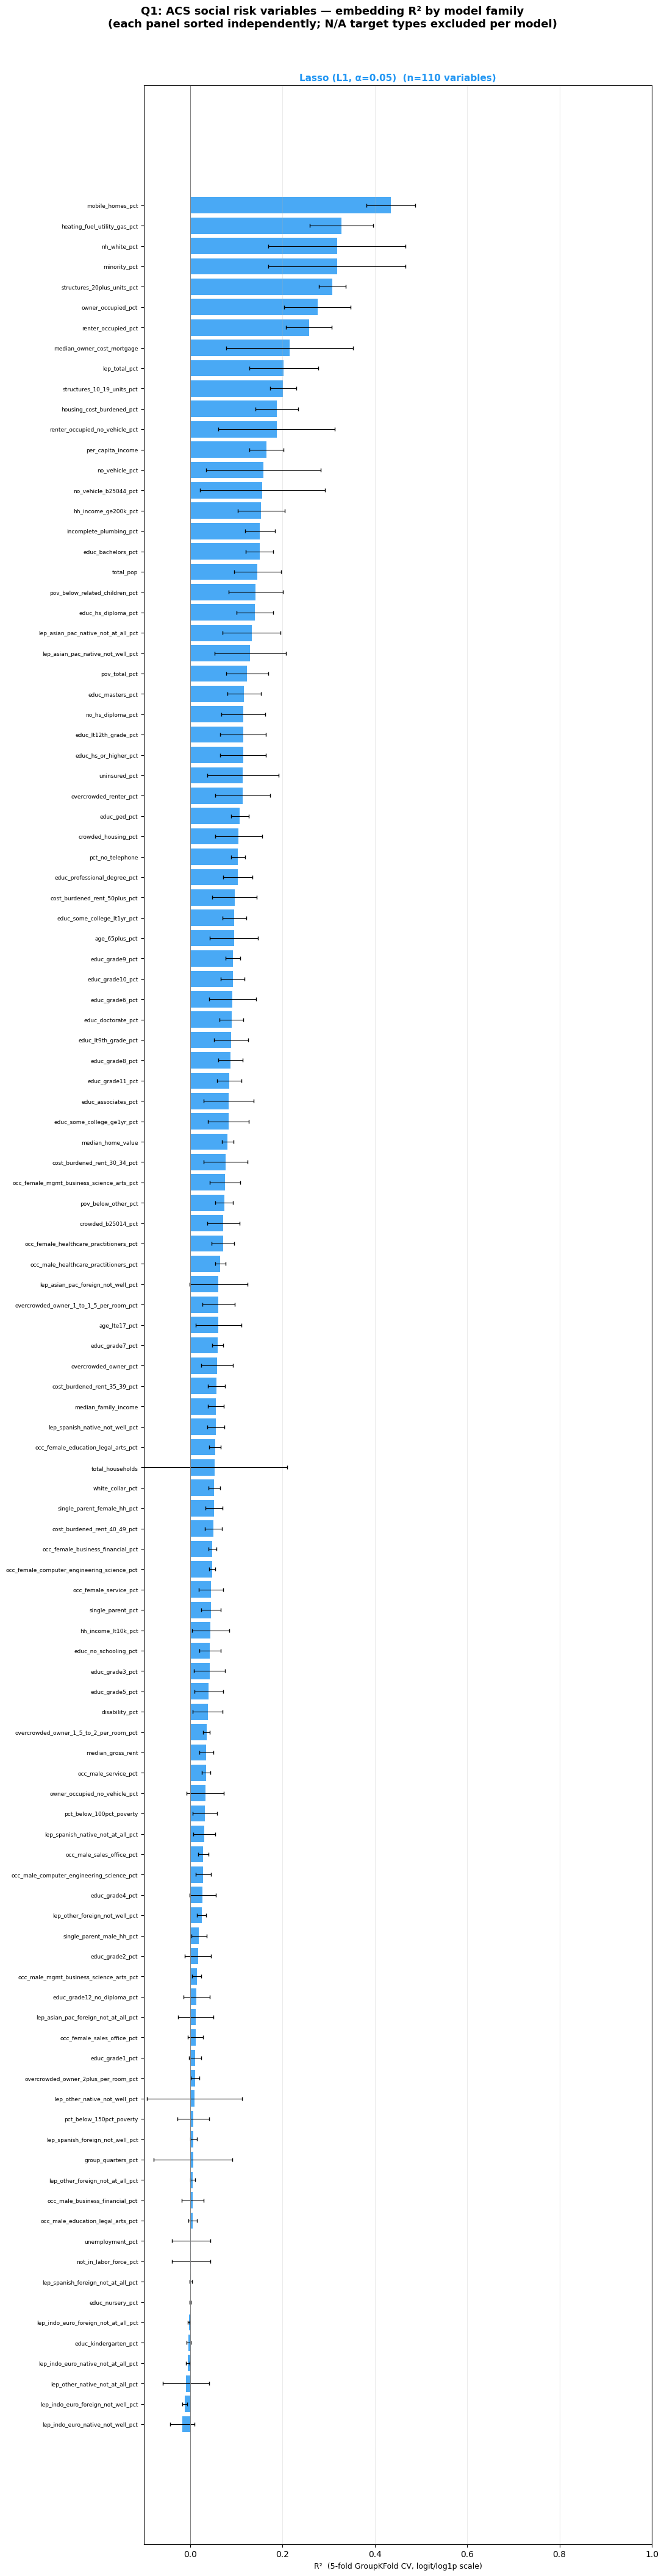

Saved → ../../outputs/other_models_cont/q1_acs_glm.png


In [35]:
# ── Q1 bar chart: one subplot per model ───────────────────────────────────────
# Each panel sorted independently (greatest to least R² for that model).
# Rows with NaN R² (model not applicable to that target type) are excluded.

active = [m for m, v in ACTIVE_MODELS.items() if v and m in q1_results]
if not active:
    print("No Q1 results available.")
else:
    # Compute max n_vars across models after dropping NaN rows, for figure height
    n_vars = max(
        len(q1_results[m].filter(
            (pl.col("group") == "ACS") & pl.col("r2_mean").is_not_null() & pl.col("r2_mean").is_finite()
        ))
        for m in active
    )

    ncols = min(len(active), 2)
    nrows = (len(active) + 1) // 2
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(11 * ncols, max(6, 0.38 * n_vars) * nrows),
        squeeze=False,
    )

    for ax_i, model_type in enumerate(active):
        ax = axes[ax_i // ncols][ax_i % ncols]

        # Drop NaN R² rows (target types not applicable to this model family)
        sub = (
            q1_results[model_type]
            .filter(
                (pl.col("group") == "ACS")
                & pl.col("r2_mean").is_not_null()
                & pl.col("r2_mean").is_finite()
            )
            .sort("r2_mean", descending=False)  # ascending so highest bar is at top
        )
        labels = [v.removesuffix("__t") for v in sub["variable"].to_list()]
        means  = sub["r2_mean"].to_list()
        stds   = [s if s is not None and np.isfinite(s) else 0.0
                  for s in sub["r2_std"].to_list()]

        ax.barh(
            range(len(labels)), means, xerr=stds,
            color=MODEL_COLORS[model_type], alpha=0.82,
            error_kw={"elinewidth": 0.8, "capsize": 2},
        )
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=6.5)
        ax.set_xlabel("R²  (5-fold GroupKFold CV, logit/log1p scale)", fontsize=9)
        ax.set_title(
            f"{MODEL_LABELS[model_type]}  (n={len(labels)} variables)",
            fontsize=11, fontweight="bold", color=MODEL_COLORS[model_type],
        )
        ax.axvline(0, color="grey", linewidth=0.7)
        ax.set_xlim(-0.1, 1.0)
        ax.grid(axis="x", alpha=0.25)

    for ax_i in range(len(active), nrows * ncols):
        axes[ax_i // ncols][ax_i % ncols].set_visible(False)

    plt.suptitle(
        "Q1: ACS social risk variables — embedding R² by model family\n"
        "(each panel sorted independently; N/A target types excluded per model)",
        fontsize=13, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "q1_acs_glm.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUTS_DIR / 'q1_acs_glm.png'}")


## Q2: Embeddings vs. social risk indices for predicting CDC PLACES outcomes

Same design as Q2 in the original notebook: 20% of states held out as test set.
Six feature sets compared: ReADI, SVI, SDI, All indices, Embeddings,
All indices + Embeddings.


In [18]:
FIPS_TO_ABBR = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT",
    "10":"DE","11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL",
    "18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD",
    "25":"MA","26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE",
    "32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY","37":"NC","38":"ND",
    "39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD",
    "47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA","54":"WV",
    "55":"WI","56":"WY",
}

readi = (
    pl.read_csv(DATA_DIR / "ReADI_CT_2022.csv", infer_schema_length=5_000)
    .select(["GEOID", "ReADI_CT_NR"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
)
sdvi = (
    pl.read_csv(DATA_DIR / "sdvi_ct_2020.csv", infer_schema_length=5_000, null_values=["NA"])
    .select(["GEOID", "SVI", "SDI", "ADI"])
    .with_columns(pl.col("GEOID").cast(pl.Utf8).str.zfill(11).alias("tract_fips"))
    .drop("GEOID")
)
df2 = (
    df.join(readi, on="tract_fips", how="inner")
      .join(sdvi,  on="tract_fips", how="left")
      .with_columns(pl.col("tract_fips").str.slice(0, 2).alias("state_fips"))
)

all_states     = sorted(df2["state_fips"].unique().to_list())
rng            = np.random.default_rng(42)
holdout_states = set(rng.choice(all_states, size=max(1, round(0.2*len(all_states))),
                                replace=False).tolist())
train_states   = set(all_states) - holdout_states

df2_pd = df2.to_pandas()
# Add logit-transformed PLACES columns
for _m in PLACES_MEASURES:
    _tc = f"{_m}__t"
    if _m in df2_pd.columns:
        df2_pd[_tc] = apply_transform(df2_pd[_m].to_numpy(dtype=float), "logit")

train_mask = df2_pd["state_fips"].isin(train_states).to_numpy()
test_mask  = df2_pd["state_fips"].isin(holdout_states).to_numpy()

READI_FEATS     = ["ReADI_CT_NR"]
SVI_FEATS       = ["SVI"]
SDI_FEATS       = ["SDI"]
ALL_INDEX_FEATS = READI_FEATS + SVI_FEATS + SDI_FEATS
COMBINED_FEATS  = ALL_INDEX_FEATS + FEATURE_COLS

print(f"Train: {len(train_states)} states  ({train_mask.sum():,} tracts)")
print(f"Test : {len(holdout_states)} states  ({test_mask.sum():,} tracts)")

Q2_FEAT_SETS = [
    (READI_FEATS,     "ReADI"),
    (SVI_FEATS,       "SVI"),
    (SDI_FEATS,       "SDI"),
    (ALL_INDEX_FEATS, "All indices"),
    (FEATURE_COLS,    "Embeddings"),
    (COMBINED_FEATS,  "All indices + Embeddings"),
]
MODEL_ORDER_Q2  = ["ReADI", "SVI", "SDI", "All indices", "Embeddings", "All indices + Embeddings"]
MODEL_COLORS_Q2 = {
    "ReADI":                    "#E53935",
    "SVI":                      "#FF7043",
    "SDI":                      "#FFA726",
    "All indices":              "#AB47BC",
    "Embeddings":               "#2196F3",
    "All indices + Embeddings": "#43A047",
}


Train: 38 states  (60,055 tracts)
Test : 10 states  (21,979 tracts)


In [21]:
%%capture cap_q2
q2_results: dict[str, pl.DataFrame] = {}

for model_type, enabled in ACTIVE_MODELS.items():
    if not enabled:
        continue
    cache_path = OUTPUTS_DIR / f"q2_places_{model_type}.csv"
    if USE_CACHED and cache_path.exists():
        q2_results[model_type] = pl.read_csv(cache_path)
        print(f"Q2 [{model_type}] loaded from cache")
        continue

    rows = []
    for col_t in PLACES_VARS_T:
        col_orig = col_t.removesuffix("__t")
        if col_t not in df2_pd.columns or col_orig not in df2_pd.columns:
            continue
        y_t   = df2_pd[col_t].to_numpy(dtype=float)
        y_raw = df2_pd[col_orig].to_numpy(dtype=float)
        valid = np.isfinite(y_t) & np.isfinite(y_raw)

        train_v = train_mask & valid
        test_v  = test_mask  & valid
        if train_v.sum() < 100 or test_v.sum() < 50:
            continue

        for feat_cols, feat_name in Q2_FEAT_SETS:
            # Filter to rows where all feature columns are finite
            feat_valid = np.all(
                np.isfinite(df2_pd[feat_cols].to_numpy(dtype=float)), axis=1
            )
            tr_v = train_v & feat_valid
            te_v = test_v  & feat_valid
            if tr_v.sum() < 50 or te_v.sum() < 20:
                continue

            X_all   = df2_pd[feat_cols].to_numpy(dtype=float)
            r2 = glm_holdout_r2(X_all, y_raw, y_t, "logit", tr_v, te_v, model_type)
            rows.append({
                "outcome": col_orig, "feature_set": feat_name,
                "model": model_type, "r2": r2,
                "n_train": int(tr_v.sum()), "n_test": int(te_v.sum()),
            })
            print(f"  [{model_type}] {col_orig} / {feat_name}: R²={r2:.3f}"
                  if np.isfinite(r2) else f"  [{model_type}] {col_orig} / {feat_name}: N/A")

    q2_results[model_type] = pl.DataFrame(rows)
    q2_results[model_type].write_csv(cache_path)
    print(f"Q2 [{model_type}] done: {len(rows)} rows saved → {cache_path.name}")


../../outputs/other_models_cont


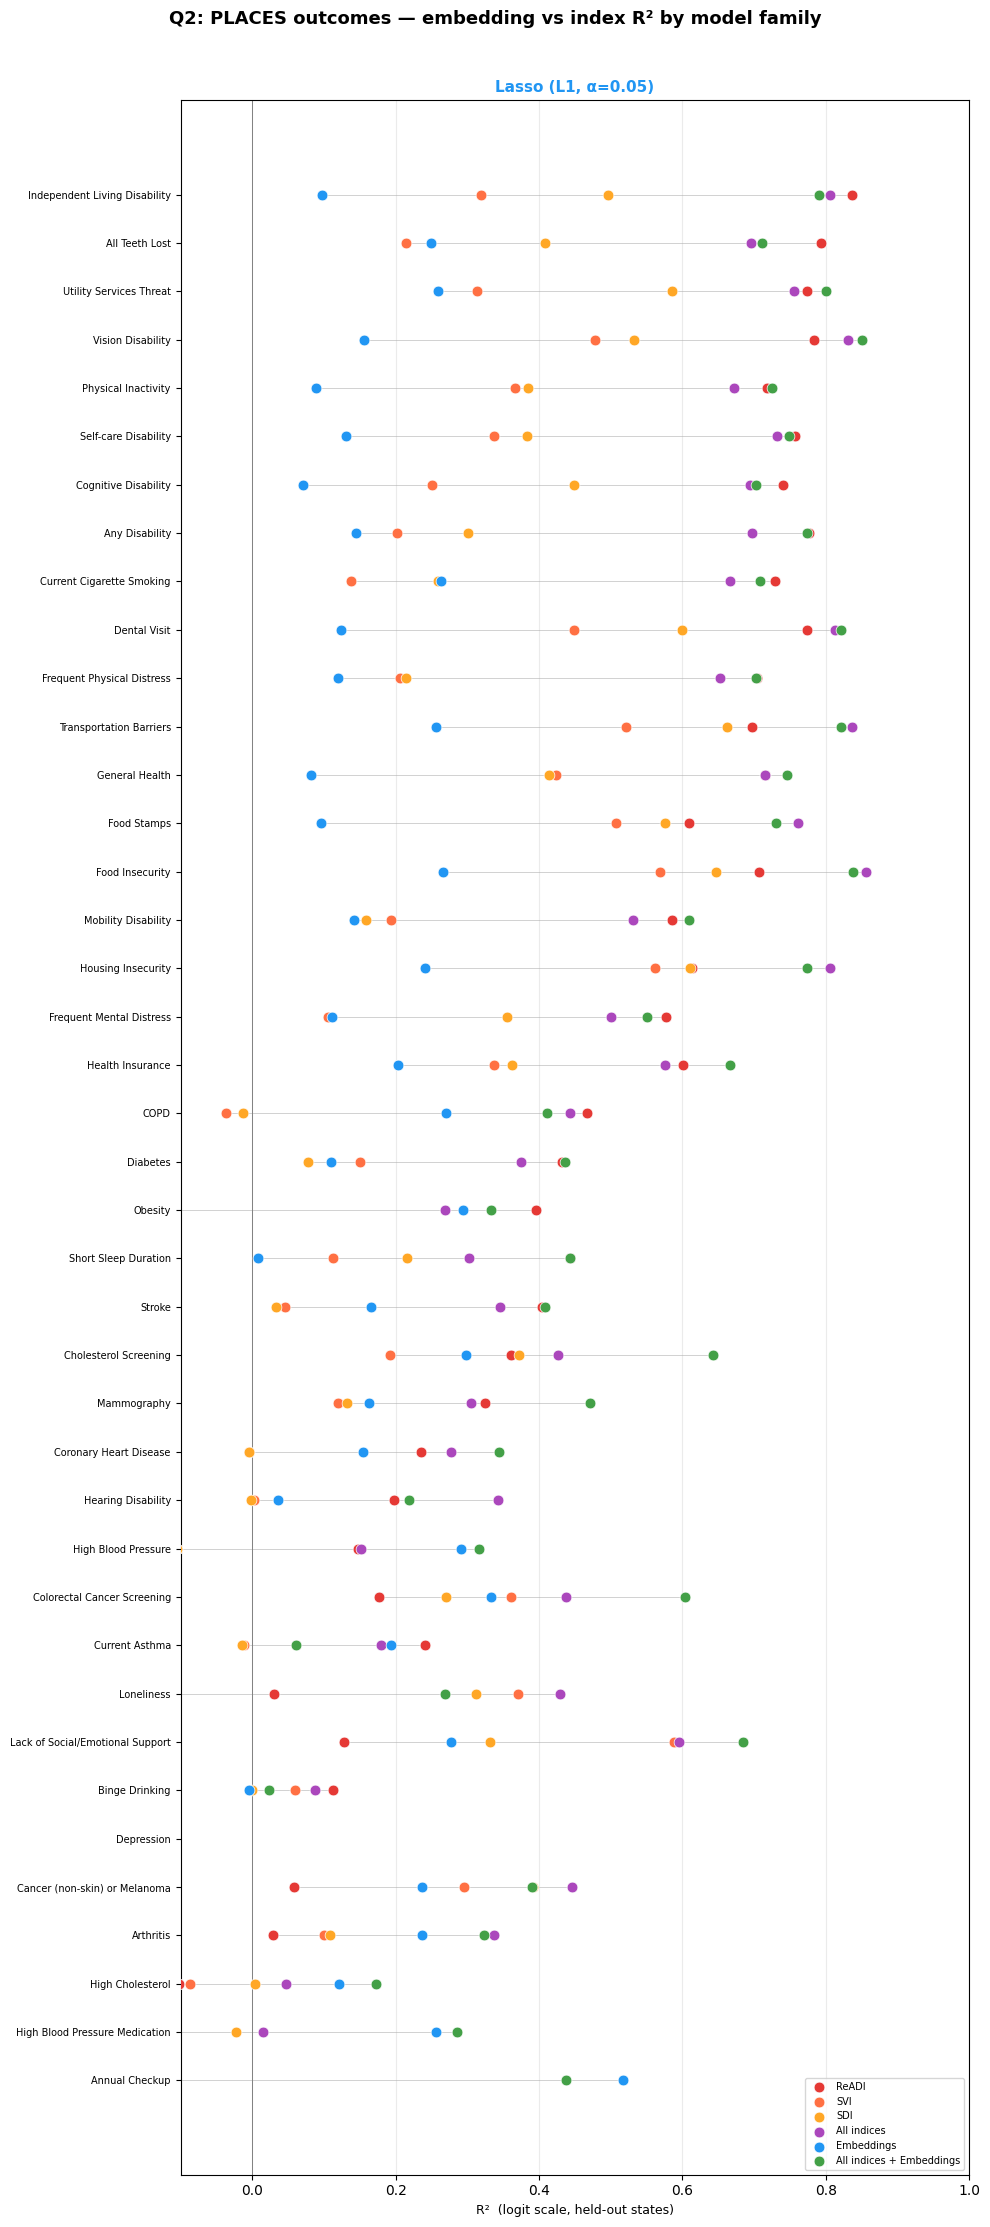

Saved → ../../outputs/other_models_cont/q2_places_glm2.png


In [ ]:
# ── Q2 dotplot: one subplot per model ─────────────────────────────────────────
active_q2 = [m for m, v in ACTIVE_MODELS.items() if v and m in q2_results]

if not active_q2:
    print("No Q2 results available.")
else:
    ref_model_q2 = "lasso" if "lasso" in active_q2 else active_q2[0]
    ref_df_q2 = q2_results[ref_model_q2]
    readi_order_q2 = (
        ref_df_q2.filter(pl.col("feature_set") == "ReADI")
        .sort("r2", nulls_last=True)["outcome"].to_list()
    )
    n_out = len(readi_order_q2)
    out_labels = [PLACES_LABELS.get(o, o) for o in readi_order_q2]

    ncols = min(len(active_q2), 2)
    nrows = (len(active_q2) + 1) // 2
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(10 * ncols, max(5, 0.55 * n_out) * nrows),
        squeeze=False,
    )

    for ax_i, model_type in enumerate(active_q2):
        ax   = axes[ax_i // ncols][ax_i % ncols]
        data = q2_results[model_type]

        for feat_name in MODEL_ORDER_Q2:
            sub = (
                data.filter(pl.col("feature_set") == feat_name)
                .with_columns(pl.col("outcome").cast(pl.Enum(readi_order_q2)))
                .sort("outcome")
            )
            ys     = [readi_order_q2.index(o) for o in sub["outcome"].to_list()]
            r2vals = sub["r2"].to_list()
            ax.scatter(r2vals, ys, color=MODEL_COLORS_Q2[feat_name], label=feat_name,
                       zorder=3, s=60, edgecolors="white", linewidths=0.5)

        # Connect dots across feature sets for each outcome
        for i, outcome in enumerate(readi_order_q2):
            vals = (
                data.filter(pl.col("outcome") == outcome)
                .sort("r2", nulls_last=True)["r2"].to_list()
            )
            finite_vals = [v for v in vals if v is not None and np.isfinite(v)]
            if len(finite_vals) >= 2:
                ax.plot([min(finite_vals), max(finite_vals)], [i, i],
                        color="grey", linewidth=0.5, zorder=1, alpha=0.5)

        ax.set_yticks(range(n_out))
        ax.set_yticklabels(out_labels, fontsize=7)
        ax.set_xlabel("R²  (logit scale, held-out states)", fontsize=9)
        ax.set_title(MODEL_LABELS[model_type], fontsize=11, fontweight="bold",
                     color=MODEL_COLORS[model_type])
        ax.axvline(0, color="grey", linewidth=0.7)
        ax.set_xlim(-0.1, 1.0)
        ax.grid(axis="x", alpha=0.25)
        if ax_i == 0:
            ax.legend(fontsize=7, loc="lower right")

    for ax_i in range(len(active_q2), nrows * ncols):
        axes[ax_i // ncols][ax_i % ncols].set_visible(False)

    plt.suptitle("Q2: PLACES outcomes — embedding vs index R² by model family",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / "q2_places_glm.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {OUTPUTS_DIR / 'q2_places_glm.png'}")


## Q3: Variance in PLACES unexplained by social indices but explained by embeddings

Two-stage residual analysis (matching the original notebook design):
- **Stage 1:** Fit social index → logit(PLACES outcome) using the GLM model.
- **Stage 2:** Fit embeddings → stage-1 residuals using **Lasso** (residuals
  are continuous, so Lasso is appropriate for all model types at stage 2).

`r2_residual` = R² of the stage-2 embedding model on held-out residuals.
`additional_var` = additional variation explained beyond the index alone.


In [31]:
%%capture cap_q3
INDEX_SETS_Q3 = [
    ("ReADI", READI_FEATS),
    ("SVI",   SVI_FEATS),
    ("SDI",   SDI_FEATS),
]

q3_results: dict[str, pl.DataFrame] = {}

for model_type, enabled in ACTIVE_MODELS.items():
    if not enabled:
        continue
    cache_path = OUTPUTS_DIR / f"q3_residual_{model_type}.csv"
    if USE_CACHED and cache_path.exists():
        q3_results[model_type] = pl.read_csv(cache_path)
        print(f"Q3 [{model_type}] loaded from cache")
        continue

    rows = []
    for col_t in PLACES_VARS_T:
        col_orig = col_t.removesuffix("__t")
        if col_t not in df2_pd.columns or col_orig not in df2_pd.columns:
            continue
        y_t   = df2_pd[col_t].to_numpy(dtype=float)
        y_raw = df2_pd[col_orig].to_numpy(dtype=float)
        valid = np.isfinite(y_t) & np.isfinite(y_raw)
        train_v = train_mask & valid
        test_v  = test_mask  & valid
        if train_v.sum() < 100 or test_v.sum() < 50:
            continue

        for index_name, index_feats in INDEX_SETS_Q3:
            X_idx = df2_pd[index_feats].to_numpy(dtype=float)
            idx_valid = np.all(np.isfinite(X_idx), axis=1)
            tr_v = train_v & idx_valid
            te_v = test_v  & idx_valid
            if tr_v.sum() < 50:
                continue

            try:
                # ── Stage 1: index → outcome (using model_type) ───────────────
                X_idx_tr_s, X_idx_te_s = _scale_fold(X_idx[tr_v], X_idx[te_v])
                r2_s1 = glm_holdout_r2(
                    X_idx, y_raw, y_t, "logit", tr_v, te_v, model_type
                )

                # Refit stage-1 to get residuals on logit scale
                y_t_tr_s1 = y_t[tr_v]
                y_t_te_s1 = y_t[te_v]

                if model_type == "lasso":
                    y_hat_tr = _fit_lasso(X_idx_tr_s, y_t_tr_s1, X_idx_tr_s)
                    y_hat_te = _fit_lasso(X_idx_tr_s, y_t_tr_s1, X_idx_te_s)
                elif model_type == "binomial_glm":
                    y_p = np.clip(y_raw / 100.0, EPS, 1 - EPS)
                    y_hat_p_tr = _fit_binomial_glm(X_idx_tr_s, y_p[tr_v], X_idx_tr_s)
                    y_hat_p_te = _fit_binomial_glm(X_idx_tr_s, y_p[tr_v], X_idx_te_s)
                    y_hat_tr = scipy_logit(y_hat_p_tr)
                    y_hat_te = scipy_logit(y_hat_p_te)
                elif model_type == "beta":
                    y_p = np.clip(y_raw / 100.0, EPS, 1 - EPS)
                    y_hat_p_tr = _fit_beta(X_idx_tr_s, y_p[tr_v], X_idx_tr_s, int(tr_v.sum()))
                    y_hat_p_te = _fit_beta(X_idx_tr_s, y_p[tr_v], X_idx_te_s, int(tr_v.sum()))
                    if y_hat_p_tr is None:
                        raise ValueError("Beta unavailable")
                    y_hat_tr = scipy_logit(y_hat_p_tr)
                    y_hat_te = scipy_logit(y_hat_p_te)
                elif model_type == "nb":
                    y_p = np.clip(y_raw / 100.0, EPS, 1 - EPS)
                    y_cnt = np.round(y_p * PSEUDO_COUNT_N).astype(int)
                    y_c_tr = _fit_nb(X_idx_tr_s, y_cnt[tr_v], X_idx_tr_s)
                    y_c_te = _fit_nb(X_idx_tr_s, y_cnt[tr_v], X_idx_te_s)
                    y_hat_tr = scipy_logit(np.clip(y_c_tr / PSEUDO_COUNT_N, EPS, 1 - EPS))
                    y_hat_te = scipy_logit(np.clip(y_c_te / PSEUDO_COUNT_N, EPS, 1 - EPS))
                else:
                    continue

                resid_tr = y_t_tr_s1 - y_hat_tr
                resid_te = y_t_te_s1 - y_hat_te

                # ── Stage 2: embeddings → residuals (always Lasso) ────────────
                X_emb = df2_pd[FEATURE_COLS].to_numpy(dtype=float)
                X_emb_tr_s, X_emb_te_s = _scale_fold(X_emb[tr_v], X_emb[te_v])
                y_pred_resid = _fit_lasso(X_emb_tr_s, resid_tr, X_emb_te_s)
                r2_resid = _r2_safe(resid_te, y_pred_resid)
                additional = float(max(0.0, r2_resid) * max(0.0, 1.0 - (r2_s1 if np.isfinite(r2_s1) else 0.0)))

                rows.append({
                    "outcome": col_orig, "index": index_name, "model": model_type,
                    "r2_stage1": r2_s1, "r2_residual": r2_resid,
                    "additional_var": additional,
                    "n_train": int(tr_v.sum()), "n_test": int(te_v.sum()),
                })
            except Exception as e:
                rows.append({
                    "outcome": col_orig, "index": index_name, "model": model_type,
                    "r2_stage1": np.nan, "r2_residual": np.nan,
                    "additional_var": np.nan,
                    "n_train": int(tr_v.sum()) if tr_v.sum() > 0 else 0,
                    "n_test": int(te_v.sum()) if te_v.sum() > 0 else 0,
                })

    q3_results[model_type] = pl.DataFrame(rows)
    q3_results[model_type].write_csv(cache_path)
    print(f"Q3 [{model_type}] done: {len(rows)} rows saved → {cache_path.name}")


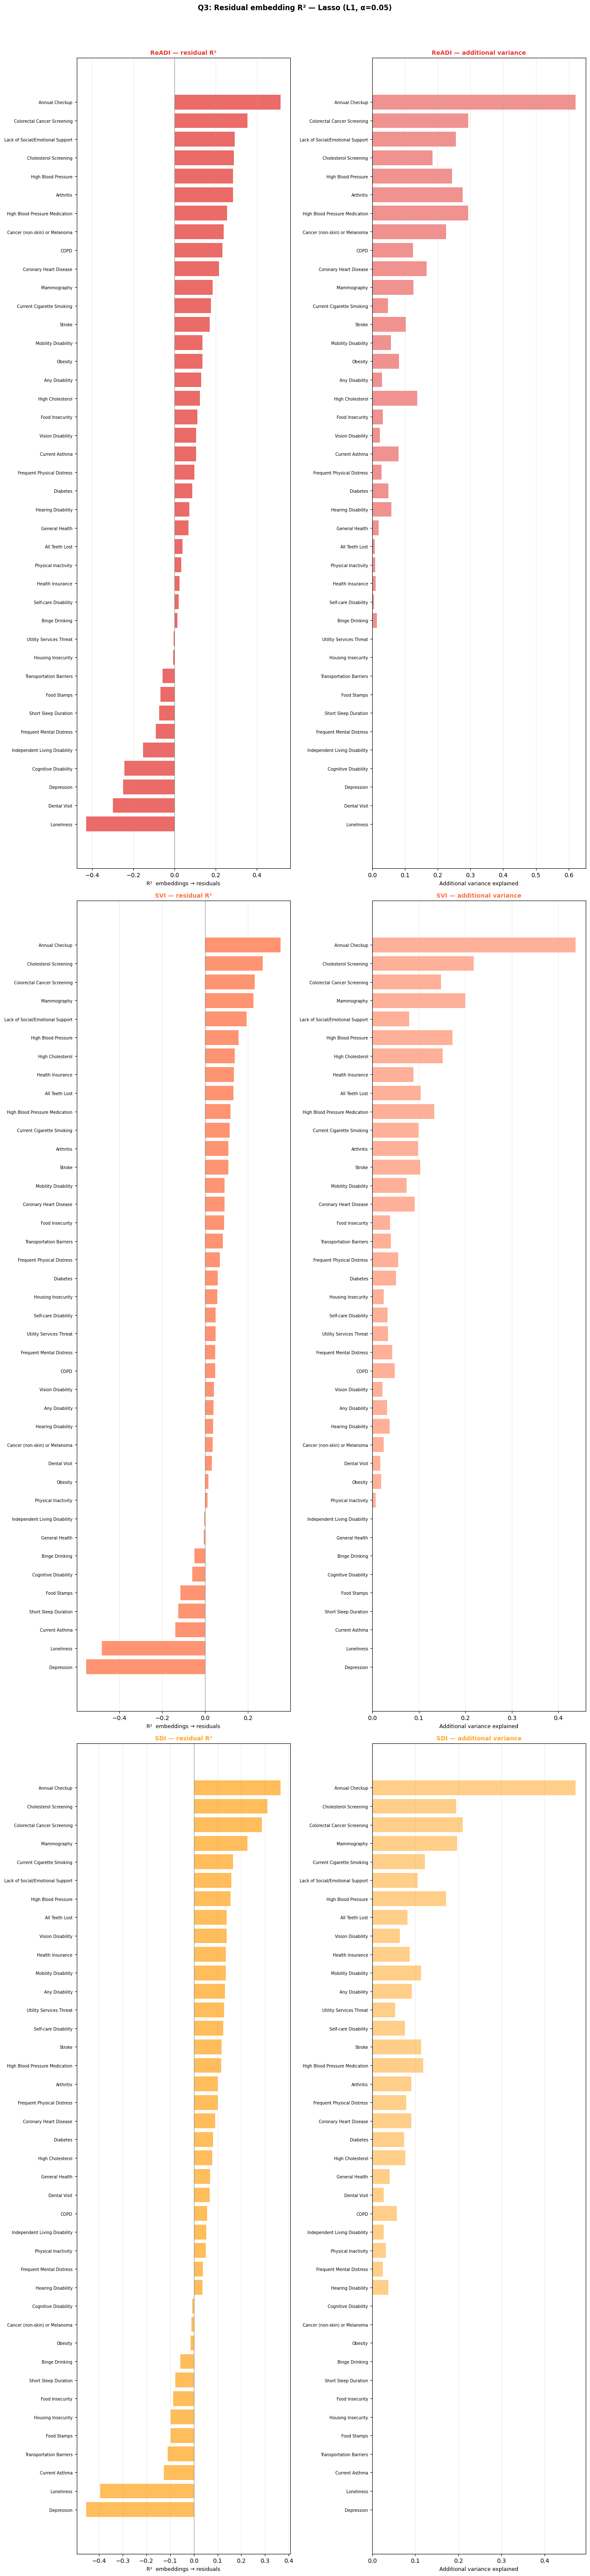

Saved → q3_residual_lasso.png


In [32]:
# ── Q3: one figure per model, each with the original 3×2 panel layout ─────────
INDEX_NAMES_Q3  = ["ReADI", "SVI", "SDI"]
INDEX_COLORS_Q3 = {"ReADI": "#E53935", "SVI": "#FF7043", "SDI": "#FFA726"}

active_q3 = [m for m, v in ACTIVE_MODELS.items() if v and m in q3_results]

for model_type in active_q3:
    data = q3_results[model_type]
    if len(data) == 0:
        print(f"[{model_type}] No Q3 data.")
        continue

    readi_order = (
        data.filter(pl.col("index") == "ReADI").sort("r2_residual", nulls_last=True)["outcome"].to_list()
    )
    svi_order   = data.filter(pl.col("index") == "SVI").sort("r2_residual", nulls_last=True)["outcome"].to_list()
    sdi_order   = data.filter(pl.col("index") == "SDI").sort("r2_residual", nulls_last=True)["outcome"].to_list()
    index_orders = {"ReADI": readi_order, "SVI": svi_order, "SDI": sdi_order}
    n_out = max(len(readi_order), 1)

    fig, axes = plt.subplots(
        len(INDEX_NAMES_Q3), 2,
        figsize=(14, max(5, 0.5 * n_out) * len(INDEX_NAMES_Q3)),
        gridspec_kw={"width_ratios": [1, 1]},
    )

    for row_i, idx_name in enumerate(INDEX_NAMES_Q3):
        order  = index_orders.get(idx_name, [])
        n_o    = len(order)
        if n_o == 0:
            axes[row_i][0].set_visible(False)
            axes[row_i][1].set_visible(False)
            continue
        y_pos  = np.arange(n_o)
        labels = [PLACES_LABELS.get(o, o) for o in order]
        color  = INDEX_COLORS_Q3[idx_name]
        sub    = (
            data.filter(pl.col("index") == idx_name)
            .with_columns(pl.col("outcome").cast(pl.Enum(order)))
            .sort("outcome")
        )

        ax0, ax1 = axes[row_i][0], axes[row_i][1]
        r2_resid   = [v if v is not None and np.isfinite(v) else 0 for v in sub["r2_residual"].to_list()]
        additional = [v if v is not None and np.isfinite(v) else 0 for v in sub["additional_var"].to_list()]

        ax0.barh(y_pos, r2_resid, color=color, alpha=0.75)
        ax0.set_yticks(y_pos); ax0.set_yticklabels(labels, fontsize=7)
        ax0.set_xlabel("R²  embeddings → residuals", fontsize=9)
        ax0.set_title(f"{idx_name} — residual R²", fontsize=10, fontweight="bold", color=color)
        ax0.axvline(0, color="grey", linewidth=0.7); ax0.grid(axis="x", alpha=0.25)

        ax1.barh(y_pos, additional, color=color, alpha=0.55)
        ax1.set_yticks(y_pos); ax1.set_yticklabels(labels, fontsize=7)
        ax1.set_xlabel("Additional variance explained", fontsize=9)
        ax1.set_title(f"{idx_name} — additional variance", fontsize=10, fontweight="bold", color=color)
        ax1.axvline(0, color="grey", linewidth=0.7); ax1.grid(axis="x", alpha=0.25)

    plt.suptitle(f"Q3: Residual embedding R² — {MODEL_LABELS[model_type]}",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    out_path = OUTPUTS_DIR / f"q3_residual_{model_type}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path.name}")


## Q4: State-level and rural/urban heterogeneity in embedding performance

Same design as Q4 in the original notebook: within-state 2-fold CV (state
scatter) and within-decile 2-fold CV (land-area decile bar charts).

> **High-dimensional note:** when feature count ≥ sample size within a state
> or decile (common for the 322-feature embedding set with small states),
> Binomial GLM / Beta / NB return NaN.  Lasso handles the p > n case via L1
> shrinkage.  For small feature sets (ReADI/SVI/SDI, p = 1–3) all models run.


In [33]:
%%capture cap_q4
q4_state_results:  dict[str, pl.DataFrame] = {}
q4_decile_results: dict[str, pl.DataFrame] = {}

X_readi_all = df2_pd[READI_FEATS].to_numpy(dtype=float)
X_svi_all   = df2_pd[SVI_FEATS].to_numpy(dtype=float)
X_sdi_all   = df2_pd[SDI_FEATS].to_numpy(dtype=float)
X_emb_all   = df2_pd[FEATURE_COLS].to_numpy(dtype=float)

# Decile breakpoints (land area)
aland   = df2_pd["ALAND"].to_numpy(dtype=float)
_edges  = np.nanpercentile(aland, np.linspace(0, 100, 11))
_edges[0] -= 1
decile_labels = np.searchsorted(_edges[1:-1], aland)

for model_type, enabled in ACTIVE_MODELS.items():
    if not enabled:
        continue
    cache_s = OUTPUTS_DIR / f"q4_state_{model_type}.csv"
    
    cache_d = OUTPUTS_DIR / f"q4_decile_{model_type}.csv"

    if USE_CACHED and cache_s.exists() and cache_d.exists():
        q4_state_results[model_type]  = pl.read_csv(cache_s)
        q4_decile_results[model_type] = pl.read_csv(cache_d)
        print(f"Q4 [{model_type}] loaded from cache")
        continue

    # ── Q4a: State-level ──────────────────────────────────────────────────────
    state_rows = []
    for state_fips in sorted(df2_pd["state_fips"].unique()):
        smask = (df2_pd["state_fips"] == state_fips).to_numpy()
        if smask.sum() < 50:
            continue
        state_abbr = FIPS_TO_ABBR.get(state_fips, state_fips)

        r2s = {"readi": [], "svi": [], "sdi": [], "emb": []}
        for col, col_t in zip(PLACES_MEASURES, PLACES_VARS_T):
            if col_t not in df2_pd.columns:
                continue
            y_t_s   = df2_pd[col_t].to_numpy(dtype=float)
            y_raw_s = df2_pd[col].to_numpy(dtype=float)
            valid   = smask & np.isfinite(y_t_s) & np.isfinite(y_raw_s)
            if valid.sum() < 20:
                continue
            idx = np.where(valid)[0]
            y_t_sub   = y_t_s[idx]
            y_raw_sub = y_raw_s[idx]

            for key, X_src in [("readi", X_readi_all), ("svi", X_svi_all),
                                ("sdi", X_sdi_all), ("emb", X_emb_all)]:
                # Drop rows where this feature set has NaN (left-joined cols like SVI/SDI)
                feat_ok = np.all(np.isfinite(X_src[idx]), axis=1)
                if feat_ok.sum() < 10:
                    r2s[key].append(np.nan)
                    continue
                r2 = glm_kfold_r2(
                    X_src[idx][feat_ok], y_raw_sub[feat_ok], y_t_sub[feat_ok],
                    "logit", model_type,
                )
                r2s[key].append(r2)

        if any(r2s["readi"]):
            state_rows.append({
                "state":      state_abbr,
                "r2_readi":   float(np.nanmean(r2s["readi"])),
                "r2_svi":     float(np.nanmean(r2s["svi"])),
                "r2_sdi":     float(np.nanmean(r2s["sdi"])),
                "r2_emb":     float(np.nanmean(r2s["emb"])),
                "n_outcomes": len(r2s["readi"]),
                "n_tracts":   int(smask.sum()),
                "model":      model_type,
            })

    # ── Q4b: Land-area deciles ─────────────────────────────────────────────────
    decile_rows = []
    for dec in range(10):
        dmask = (decile_labels == dec)
        if dmask.sum() < 20:
            continue
        r2s = {"readi": [], "svi": [], "sdi": [], "emb": []}
        for col, col_t in zip(PLACES_MEASURES, PLACES_VARS_T):
            if col_t not in df2_pd.columns:
                continue
            y_t_d   = df2_pd[col_t].to_numpy(dtype=float)
            y_raw_d = df2_pd[col].to_numpy(dtype=float)
            valid   = dmask & np.isfinite(y_t_d) & np.isfinite(y_raw_d)
            if valid.sum() < 10:
                continue
            idx = np.where(valid)[0]

            for key, X_src in [("readi", X_readi_all), ("svi", X_svi_all),
                                ("sdi", X_sdi_all), ("emb", X_emb_all)]:
                # Drop rows where this feature set has NaN (left-joined cols like SVI/SDI)
                feat_ok = np.all(np.isfinite(X_src[idx]), axis=1)
                if feat_ok.sum() < 10:
                    r2s[key].append(np.nan)
                    continue
                r2 = glm_kfold_r2(
                    X_src[idx][feat_ok], y_raw_d[idx][feat_ok], y_t_d[idx][feat_ok],
                    "logit", model_type,
                )
                r2s[key].append(r2)

        if any(r2s["readi"]):
            decile_rows.append({
                "decile":           dec,
                "r2_readi":         float(np.nanmean(r2s["readi"])),
                "r2_svi":           float(np.nanmean(r2s["svi"])),
                "r2_sdi":           float(np.nanmean(r2s["sdi"])),
                "r2_emb":           float(np.nanmean(r2s["emb"])),
                "n_tracts":         int(dmask.sum()),
                "median_aland_km2": float(np.nanmedian(aland[dmask]) / 1e6),
                "model":            model_type,
            })

    q4_state_results[model_type]  = pl.DataFrame(state_rows)
    q4_decile_results[model_type] = pl.DataFrame(decile_rows)
    q4_state_results[model_type].write_csv(cache_s)
    q4_decile_results[model_type].write_csv(cache_d)
    print(f"Q4 [{model_type}] done: {len(state_rows)} states, {len(decile_rows)} deciles → cached")


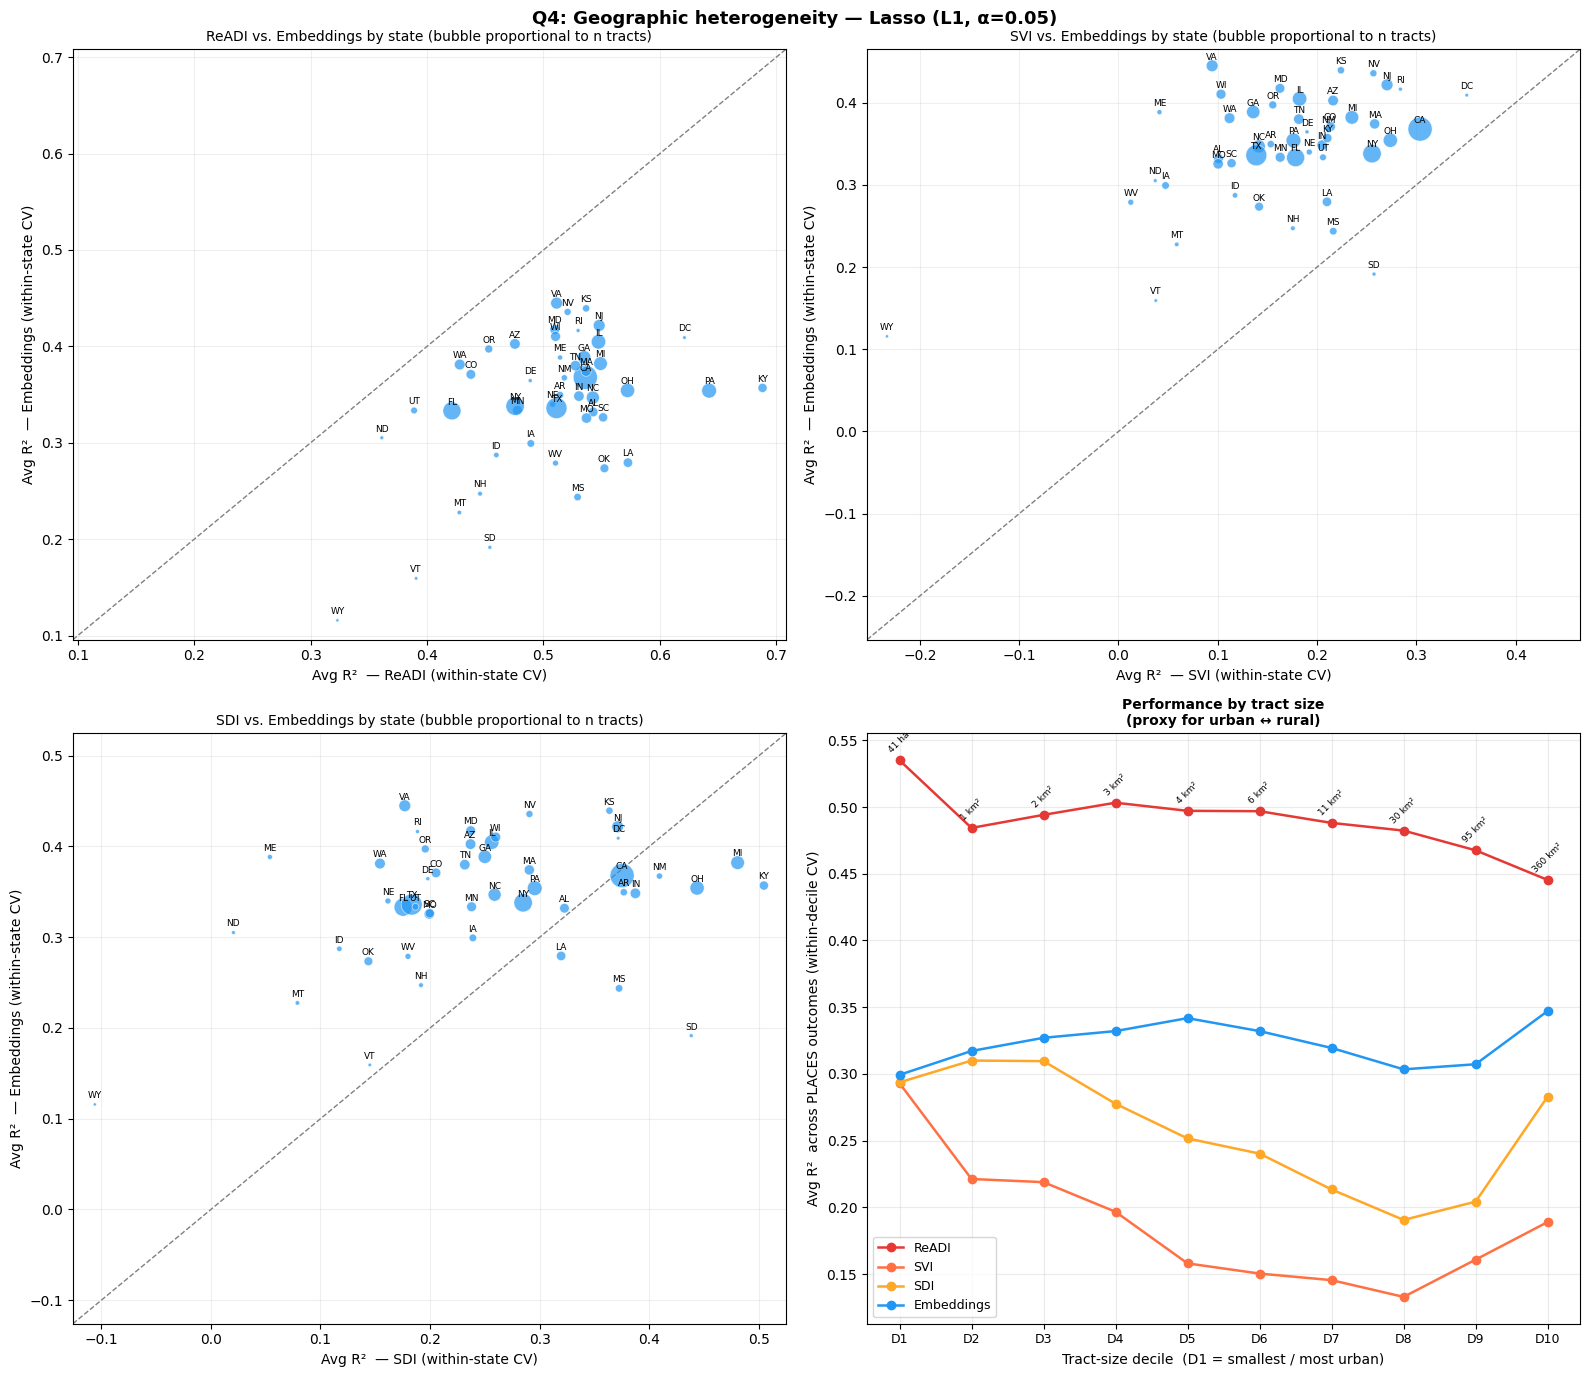

Saved → q4_heterogeneity_lasso.png


In [34]:
# ── Q4 plots: one figure per model (2×2 scatter + decile bar) ─────────────────
active_q4 = [m for m, v in ACTIVE_MODELS.items() if v
             and m in q4_state_results and len(q4_state_results[m]) > 0]

for model_type in active_q4:
    s_df = q4_state_results[model_type].to_pandas()
    d_df = q4_decile_results[model_type].sort("decile").to_pandas()

    if len(s_df) == 0:
        print(f"[{model_type}] No Q4 state data.")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    def state_scatter(ax, index_col, index_label, index_color):
        ax.scatter(s_df[index_col], s_df["r2_emb"],
                   s=s_df["n_tracts"] / 30, color="#2196F3",
                   alpha=0.7, edgecolors="white", linewidths=0.5, zorder=3)
        for _, row in s_df.iterrows():
            ax.annotate(row["state"], (row[index_col], row["r2_emb"]),
                        fontsize=6.5, ha="center", va="bottom",
                        xytext=(0, 3), textcoords="offset points")
        all_vals = pd.concat([s_df[index_col], s_df["r2_emb"]]).dropna()
        if len(all_vals) == 0:
            return
        lim = [all_vals.min() - 0.02, all_vals.max() + 0.02]
        ax.plot(lim, lim, color="grey", linewidth=1, linestyle="--", zorder=2)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel(f"Avg R²  — {index_label} (within-state CV)", fontsize=10)
        ax.set_ylabel("Avg R²  — Embeddings (within-state CV)", fontsize=10)
        ax.set_title(f"{index_label} vs. Embeddings by state (bubble proportional to n tracts)", fontsize=10)
        ax.grid(alpha=0.2)

    import pandas as pd  # noqa: F811 — already imported above via polars
    try:
        import pandas as _pd
    except ImportError:
        pass

    state_scatter(axes[0][0], "r2_readi", "ReADI", "#E53935")
    state_scatter(axes[0][1], "r2_svi",   "SVI",   "#FF7043")
    state_scatter(axes[1][0], "r2_sdi",   "SDI",   "#FFA726")

    # Decile line plot (bottom-right) — matches analyses_transformed style
    ax_d = axes[1][1]
    if len(d_df) > 0:
        for key, label, color in [
            ("r2_readi", "ReADI",       "#E53935"),
            ("r2_svi",   "SVI",         "#FF7043"),
            ("r2_sdi",   "SDI",         "#FFA726"),
            ("r2_emb",   "Embeddings",  "#2196F3"),
        ]:
            ax_d.plot(d_df["decile"], d_df[key],
                      color=color, marker="o", linewidth=1.8, markersize=6, label=label)
        if "median_aland_km2" in d_df.columns:
            for _, row in d_df.iterrows():
                km2 = row["median_aland_km2"]
                area_str = (f"{km2:.0f} km²" if km2 >= 1 else f"{km2*100:.0f} ha")
                top_r2 = max(
                    row["r2_readi"] if row["r2_readi"] == row["r2_readi"] else -np.inf,
                    row["r2_svi"]   if row["r2_svi"]   == row["r2_svi"]   else -np.inf,
                    row["r2_sdi"]   if row["r2_sdi"]   == row["r2_sdi"]   else -np.inf,
                    row["r2_emb"]   if row["r2_emb"]   == row["r2_emb"]   else -np.inf,
                )
                if np.isfinite(top_r2):
                    ax_d.annotate(area_str, (row["decile"], top_r2),
                                  fontsize=6.5, ha="center", va="bottom",
                                  xytext=(0, 4), textcoords="offset points", rotation=45)
        ax_d.set_xticks(d_df["decile"].tolist())
        ax_d.set_xticklabels([f"D{d+1}" for d in d_df["decile"].tolist()], fontsize=9)
        ax_d.set_xlabel("Tract-size decile  (D1 = smallest / most urban)", fontsize=10)
        ax_d.set_ylabel("Avg R²  across PLACES outcomes (within-decile CV)", fontsize=10)
        ax_d.set_title("Performance by tract size\n(proxy for urban \u2194 rural)",
                        fontsize=10, fontweight="bold")
        ax_d.legend(fontsize=9)
        ax_d.grid(alpha=0.25)

    plt.suptitle(f"Q4: Geographic heterogeneity — {MODEL_LABELS[model_type]}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_path = OUTPUTS_DIR / f"q4_heterogeneity_{model_type}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path.name}")


## Lasso Hyperparameter Search

Sweep a grid of fixed alphas, sklearn `LassoCV` (inner 3-fold auto-select), and two ElasticNet (L1+L2) variants.  
Evaluation design: same 5-fold **GroupKFold by state** as Q1, R² on the logit/log1p transformed scale.  
Results cached per config to `outputs/other_models/q1_lasso_cfg_<key>.csv`.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Lasso / ElasticNet alpha search
#
# Configs: fixed-alpha Lasso grid  +  LassoCV (auto)  +  ElasticNet variants
# Per variable we record: r2_mean, r2_std, median optimal alpha, median nonzero
# ─────────────────────────────────────────────────────────────────────────────

import warnings as _warn

LASSO_ALPHA_GRID = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]

# (label, model_type, constructor_kwargs)
LASSO_CONFIGS = {
    "lasso_cv":   ("LassoCV (auto α)",        "lasso_cv",    {}),
    "lasso_a001": ("Lasso α=0.001",            "lasso_fixed", {"alpha": 0.001, "max_iter": 5000}),
    "lasso_a005": ("Lasso α=0.005",            "lasso_fixed", {"alpha": 0.005, "max_iter": 5000}),
    "lasso_a010": ("Lasso α=0.010",            "lasso_fixed", {"alpha": 0.010, "max_iter": 5000}),
    "lasso_a020": ("Lasso α=0.020",            "lasso_fixed", {"alpha": 0.020, "max_iter": 3000}),
    "lasso_a050": ("Lasso α=0.050  [default]", "lasso_fixed", {"alpha": 0.050, "max_iter": 3000}),
    "lasso_a100": ("Lasso α=0.100",            "lasso_fixed", {"alpha": 0.100, "max_iter": 3000}),
    "lasso_a200": ("Lasso α=0.200",            "lasso_fixed", {"alpha": 0.200, "max_iter": 3000}),
    "enet_l1_80": ("ElasticNet α=0.05 L1=0.80","elasticnet",  {"alpha": 0.05, "l1_ratio": 0.80, "max_iter": 3000}),
    "enet_l1_50": ("ElasticNet α=0.05 L1=0.50","elasticnet",  {"alpha": 0.05, "l1_ratio": 0.50, "max_iter": 3000}),
}
LASSO_CONFIG_LABELS = {k: v[0] for k, v in LASSO_CONFIGS.items()}
LASSO_CONFIG_COLORS = {
    "lasso_cv":   "#9C27B0",
    "lasso_a001": "#BBDEFB", "lasso_a005": "#90CAF9", "lasso_a010": "#64B5F6",
    "lasso_a020": "#42A5F5", "lasso_a050": "#2196F3", "lasso_a100": "#1976D2",
    "lasso_a200": "#0D47A1",
    "enet_l1_80": "#FF7043", "enet_l1_50": "#FF8A65",
}


def _lasso_cfg_cv(
    X: np.ndarray,
    y_t: np.ndarray,
    groups: np.ndarray,
    cfg_type: str,
    cfg_kwargs: dict,
    n_splits: int = 5,
) -> tuple[float, float, float, float]:
    """
    GroupKFold CV for one Lasso/ElasticNet config.
    Returns (mean_r2, std_r2, median_alpha, median_n_nonzero).
    """
    scores, alphas, n_nzeros = [], [], []

    for tr_idx, val_idx in GroupKFold(n_splits=n_splits).split(X, y_t, groups=groups):
        X_tr_s, X_val_s = _scale_fold(X[tr_idx], X[val_idx])
        y_tr, y_val = y_t[tr_idx], y_t[val_idx]
        try:
            with _warn.catch_warnings():
                _warn.simplefilter("ignore")
                if cfg_type == "lasso_cv":
                    m = LassoCV(
                        alphas=LASSO_ALPHA_GRID, cv=3,
                        max_iter=5000, random_state=42,
                    ).fit(X_tr_s, y_tr)
                    alphas.append(float(m.alpha_))
                    n_nzeros.append(int(np.sum(m.coef_ != 0)))
                    pred = m.predict(X_val_s)
                elif cfg_type == "lasso_fixed":
                    m = Lasso(**cfg_kwargs).fit(X_tr_s, y_tr)
                    alphas.append(cfg_kwargs["alpha"])
                    n_nzeros.append(int(np.sum(m.coef_ != 0)))
                    pred = m.predict(X_val_s)
                elif cfg_type == "elasticnet":
                    m = ElasticNet(**cfg_kwargs).fit(X_tr_s, y_tr)
                    alphas.append(cfg_kwargs["alpha"])
                    n_nzeros.append(int(np.sum(m.coef_ != 0)))
                    pred = m.predict(X_val_s)
                else:
                    scores.append(np.nan)
                    continue
            scores.append(_r2_safe(y_val, pred))
        except Exception:
            scores.append(np.nan)

    valid = [s for s in scores if np.isfinite(s)]
    return (
        float(np.mean(valid)) if valid else np.nan,
        float(np.std(valid))  if valid else np.nan,
        float(np.median(alphas))   if alphas  else np.nan,
        float(np.median(n_nzeros)) if n_nzeros else np.nan,
    )


# ── Run ────────────────────────────────────────────────────────────────────────
q1_lasso_configs: dict[str, "pl.DataFrame"] = {}
_X_ls  = df_pd[FEATURE_COLS].to_numpy(dtype=float)
_grp_ls = df_pd["tract_fips"].str[:2].to_numpy()

for cfg_key, (cfg_label, cfg_type, cfg_kwargs) in LASSO_CONFIGS.items():
    cache_path = OUTPUTS_DIR / f"q1_lasso_cfg_{cfg_key}.csv"
    if USE_CACHED and cache_path.exists():
        q1_lasso_configs[cfg_key] = pl.read_csv(cache_path)
        print(f"[CACHE]  {cfg_key:<12}  {cfg_label:<42}  ({len(q1_lasso_configs[cfg_key])} vars)")
        continue

    print(f"\n{'─'*72}")
    print(f"  Config: {cfg_key}  |  {cfg_label}")
    print(f"{'─'*72}")

    rows = []
    for v_i, col in enumerate(ACS_VARS_T):
        if col not in df_pd.columns:
            continue
        orig_var  = col.removesuffix("__t")
        transform = ACS_T_METHOD.get(col, "logit")
        raw_col   = orig_var if orig_var in df_pd.columns else None
        y_t_arr   = df_pd[col].to_numpy(dtype=float)
        y_raw_arr = (df_pd[raw_col].to_numpy(dtype=float)
                     if raw_col is not None else np.zeros(len(y_t_arr)))
        mask = np.isfinite(y_t_arr) & np.isfinite(y_raw_arr)
        if mask.sum() < 100:
            continue

        r2_mean, r2_std, alpha_used, n_nz = _lasso_cfg_cv(
            _X_ls[mask], y_t_arr[mask], _grp_ls[mask], cfg_type, cfg_kwargs,
        )
        rows.append({
            "variable": col, "orig_var": orig_var, "transform": transform,
            "r2_mean": r2_mean, "r2_std": r2_std,
            "alpha_used": alpha_used, "n_nonzero": n_nz,
        })
        if np.isfinite(r2_mean):
            print(f"  [{v_i+1:2d}] {orig_var:<30s}  R²={r2_mean:.3f} ±{r2_std:.3f}"
                  f"  α={alpha_used:.4f}  nz={n_nz:.0f}")
        else:
            print(f"  [{v_i+1:2d}] {orig_var:<30s}  R²=N/A")

    df_r = (
        pl.DataFrame(rows)
        .with_columns(
            pl.col("orig_var").map_elements(
                lambda v: ", ".join(sorted(INDEX_MEMBERSHIP.get(v, set()))),
                return_dtype=pl.Utf8,
            ).alias("indices")
        )
        .sort("r2_mean", descending=True, nulls_last=True)
    )
    q1_lasso_configs[cfg_key] = df_r
    df_r.write_csv(cache_path)
    print(f"\n  → Saved {len(rows)} vars  →  {cache_path.name}")

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print(f"  Summary: mean R² across all ACS variables  (finite values only)")
print(f"{'='*72}")
print(f"  {'Config':<12}  {'Label':<42}  {'mean_all':>8}  {'top5_mean':>9}")
print(f"  {'─'*12}  {'─'*42}  {'─'*8}  {'─'*9}")

_summary = []
for cfg_key, df_c in q1_lasso_configs.items():
    vals   = [v for v in df_c["r2_mean"].to_list() if v is not None and np.isfinite(v)]
    top5   = sorted(vals, reverse=True)[:5]
    m_all  = float(np.mean(vals)) if vals else np.nan
    m_top5 = float(np.mean(top5)) if top5 else np.nan
    _summary.append({"cfg": cfg_key, "mean_all": m_all, "mean_top5": m_top5})
    lbl = LASSO_CONFIG_LABELS[cfg_key]
    print(f"  {cfg_key:<12}  {lbl:<42}  {m_all:8.4f}  {m_top5:9.4f}")

_best_cfg = max(_summary, key=lambda x: x["mean_top5"] if np.isfinite(x["mean_top5"]) else -np.inf)["cfg"]
print(f"\n  Best by top-5 mean R²: {_best_cfg}  [{LASSO_CONFIG_LABELS[_best_cfg]}]")
print("\nDone. Run the plotting cell below to visualise.")



────────────────────────────────────────────────────────────────────────
  Config: lasso_cv  |  LassoCV (auto α)
────────────────────────────────────────────────────────────────────────
  [ 1] median_family_income            R²=0.060 ±0.019  α=0.0010  nz=215
  [ 2] per_capita_income               R²=0.179 ±0.037  α=0.0010  nz=195
  [ 3] median_gross_rent               R²=0.017 ±0.049  α=0.0010  nz=211
  [ 4] median_home_value               R²=0.074 ±0.021  α=0.0010  nz=233
  [ 5] unemployment_pct                R²=0.011 ±0.029  α=0.0010  nz=191
  [ 6] total_pop                       R²=0.148 ±0.051  α=0.2000  nz=302
  [ 7] age_lte17_pct                   R²=0.042 ±0.092  α=0.0010  nz=190
  [ 8] total_households                R²=0.056 ±0.154  α=0.0500  nz=309
  [ 9] single_parent_male_hh_pct       R²=0.018 ±0.017  α=0.0050  nz=113
  [10] single_parent_female_hh_pct     R²=0.022 ±0.035  α=0.0010  nz=227
  [11] disability_pct                  R²=0.033 ±0.094  α=0.0010  nz=173
  [12] str

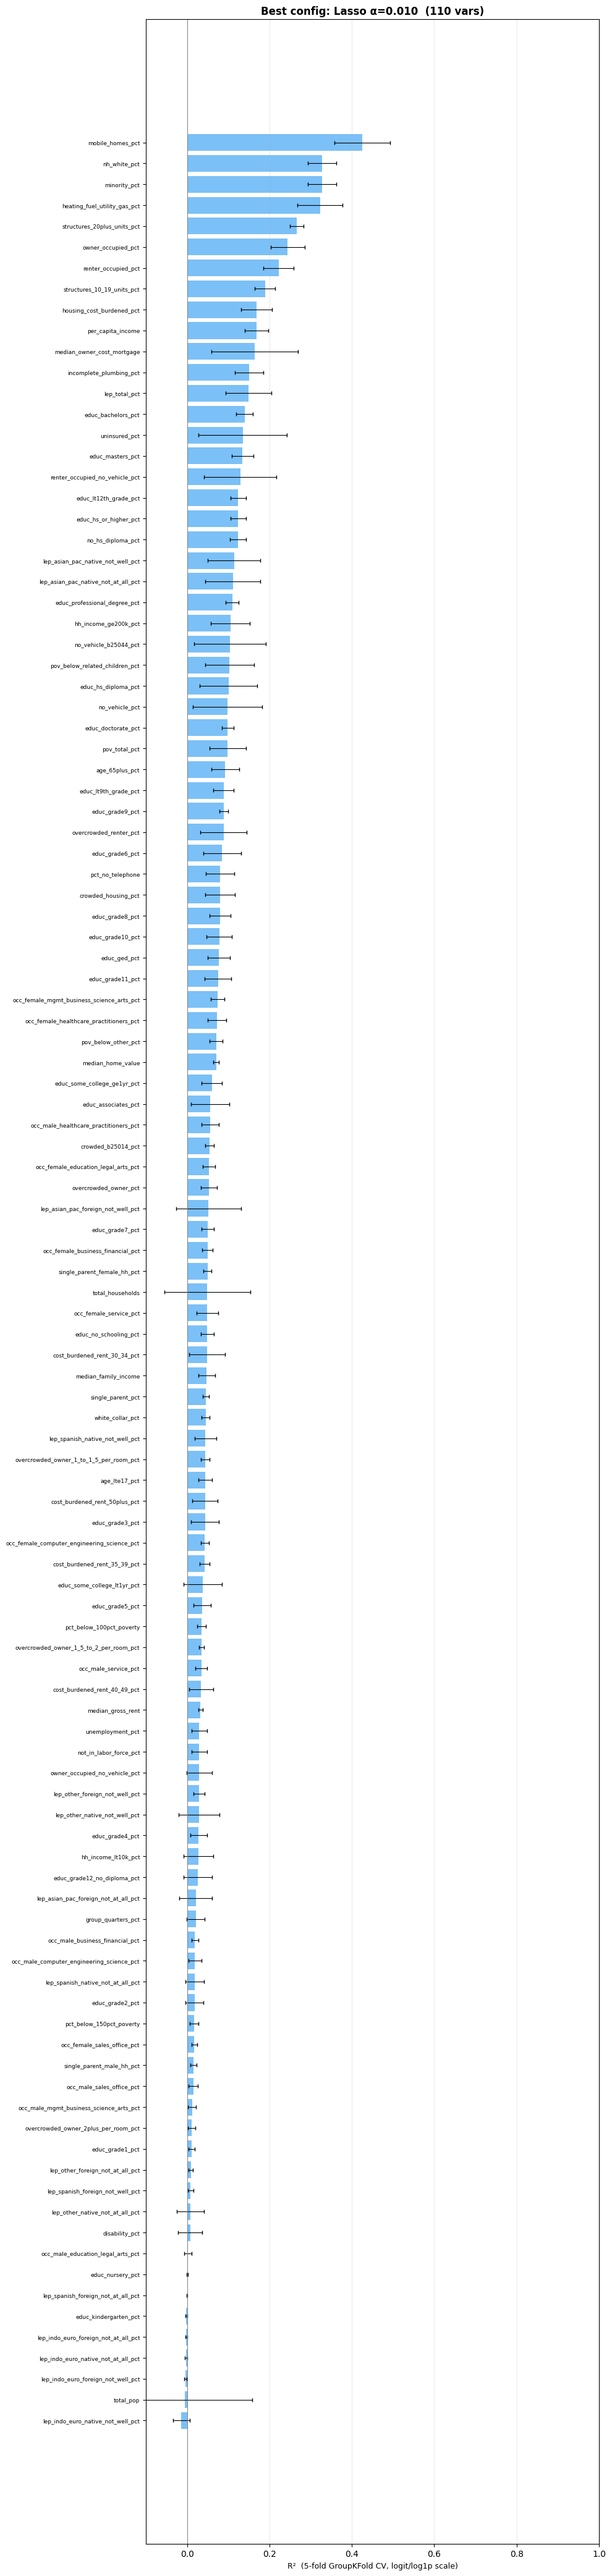

Saved → q1_lasso_best_lasso_a010.png


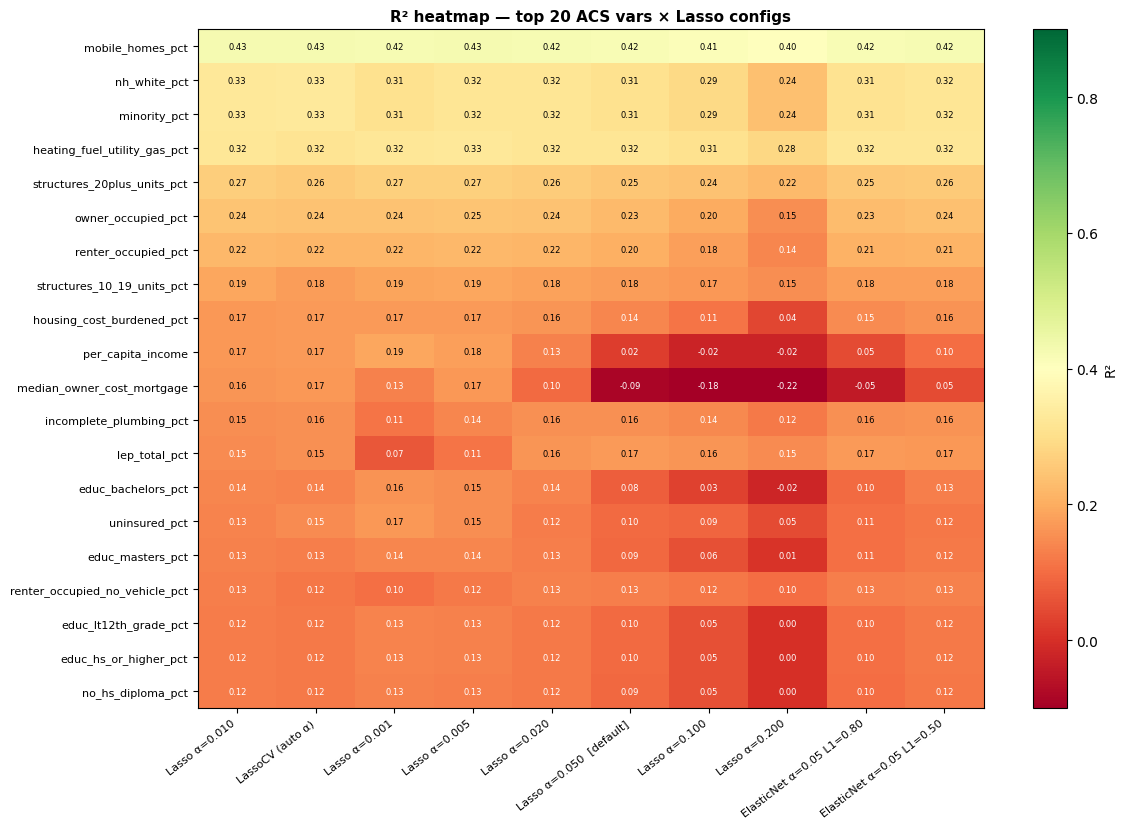

Saved → q1_lasso_heatmap.png


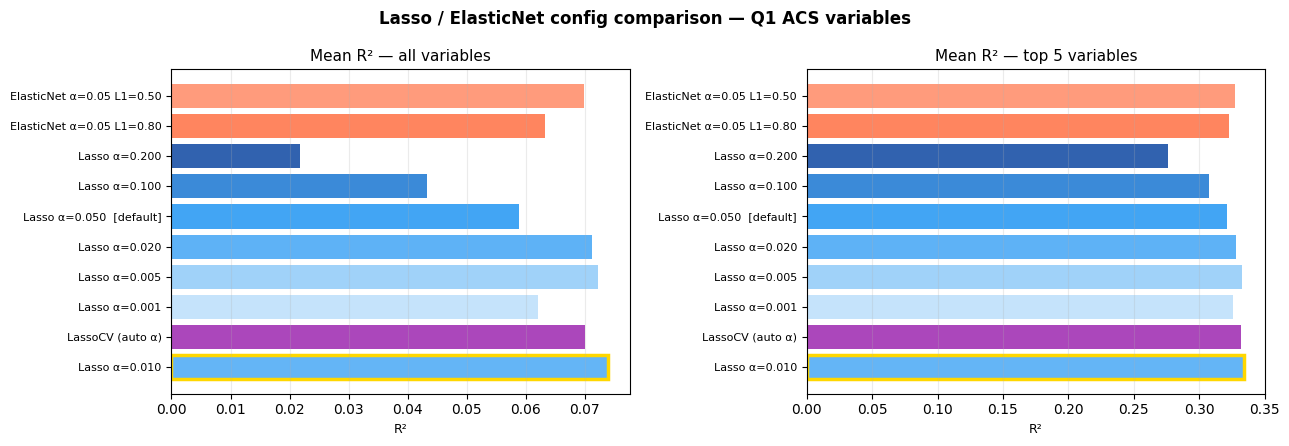

Saved → q1_lasso_summary.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Lasso config comparison plots
#
# PLOT_CONFIGS — list of config keys to show, or None for all
#   Default = [best config first, then rest in definition order]
# TOP_N_VARS  — how many top variables to show in the heatmap
# ─────────────────────────────────────────────────────────────────────────────

PLOT_CONFIGS = None  # e.g. ["lasso_cv", "lasso_a050", "enet_l1_80"]
TOP_N_VARS   = 20

if not q1_lasso_configs:
    print("No LassoCV results. Run the modeling cell above first.")
else:
    # Derive best config from current results (works if modeling cell wasn't run yet)
    _summ2 = []
    for _ck, _dc in q1_lasso_configs.items():
        _vals = [v for v in _dc["r2_mean"].to_list() if v is not None and np.isfinite(v)]
        _t5   = sorted(_vals, reverse=True)[:5]
        _summ2.append((_ck, float(np.mean(_t5)) if _t5 else np.nan))
    best_cfg = max(_summ2, key=lambda x: x[1] if np.isfinite(x[1]) else -np.inf)[0]

    _all_cfgs  = list(q1_lasso_configs.keys())
    _plot_cfgs = (
        PLOT_CONFIGS
        if PLOT_CONFIGS
        else [best_cfg] + [c for c in _all_cfgs if c != best_cfg]
    )

    # ── Plot 1: Bar chart — best config ───────────────────────────────────────
    _df_best = (
        q1_lasso_configs[best_cfg]
        .filter(pl.col("r2_mean").is_not_null() & pl.col("r2_mean").is_finite())
        .sort("r2_mean", descending=False)
    )
    _labels = [v.removesuffix("__t") for v in _df_best["variable"].to_list()]
    _means  = _df_best["r2_mean"].to_list()
    _stds   = [s if (s is not None and np.isfinite(s)) else 0.0
               for s in _df_best["r2_std"].to_list()]

    fig, ax = plt.subplots(figsize=(10, max(6, 0.38 * len(_labels))))
    ax.barh(
        range(len(_labels)), _means, xerr=_stds,
        color=LASSO_CONFIG_COLORS.get(best_cfg, "#2196F3"), alpha=0.85,
        error_kw={"elinewidth": 0.8, "capsize": 2},
    )
    ax.set_yticks(range(len(_labels)))
    ax.set_yticklabels(_labels, fontsize=6.5)
    ax.set_xlabel("R²  (5-fold GroupKFold CV, logit/log1p scale)", fontsize=9)
    ax.set_title(
        f"Best config: {LASSO_CONFIG_LABELS[best_cfg]}  ({len(_labels)} vars)",
        fontsize=12, fontweight="bold",
    )
    ax.axvline(0, color="grey", linewidth=0.7)
    ax.set_xlim(-0.1, 1.0)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    _p1 = OUTPUTS_DIR / f"q1_lasso_best_{best_cfg}.png"
    plt.savefig(_p1, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_p1.name}")

    # ── Plot 2: Heatmap — top N vars × all configs ────────────────────────────
    _top_vars = (
        q1_lasso_configs[best_cfg]
        .filter(pl.col("r2_mean").is_not_null() & pl.col("r2_mean").is_finite())
        .sort("r2_mean", descending=True)
        .head(TOP_N_VARS)["variable"]
        .to_list()
    )
    _top_labels = [v.removesuffix("__t") for v in _top_vars]
    _mat = np.full((len(_top_vars), len(_plot_cfgs)), np.nan)
    for _ci, _cfg in enumerate(_plot_cfgs):
        _dc = q1_lasso_configs[_cfg]
        for _ri, _var in enumerate(_top_vars):
            _row = _dc.filter(pl.col("variable") == _var)
            if len(_row) > 0:
                _v = _row["r2_mean"][0]
                _mat[_ri, _ci] = _v if (_v is not None and np.isfinite(_v)) else np.nan

    fig, ax = plt.subplots(figsize=(max(9, 1.2 * len(_plot_cfgs)), max(6, 0.42 * TOP_N_VARS)))
    _im = ax.imshow(_mat, aspect="auto", cmap="RdYlGn", vmin=-0.1, vmax=0.9)
    plt.colorbar(_im, ax=ax, label="R²")
    ax.set_xticks(range(len(_plot_cfgs)))
    ax.set_xticklabels(
        [LASSO_CONFIG_LABELS[c] for c in _plot_cfgs],
        rotation=38, ha="right", fontsize=8,
    )
    ax.set_yticks(range(len(_top_labels)))
    ax.set_yticklabels(_top_labels, fontsize=8)
    ax.set_title(
        f"R² heatmap — top {TOP_N_VARS} ACS vars × Lasso configs",
        fontsize=11, fontweight="bold",
    )
    for _r in range(_mat.shape[0]):
        for _c in range(_mat.shape[1]):
            _v = _mat[_r, _c]
            if np.isfinite(_v):
                ax.text(_c, _r, f"{_v:.2f}", ha="center", va="center", fontsize=6,
                        color="black" if 0.15 < _v < 0.75 else "white")
    plt.tight_layout()
    _p2 = OUTPUTS_DIR / "q1_lasso_heatmap.png"
    plt.savefig(_p2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_p2.name}")

    # ── Plot 3: Summary bar — mean R² per config ──────────────────────────────
    _cfg_stats = []
    for _cfg in _plot_cfgs:
        _vals = [v for v in q1_lasso_configs[_cfg]["r2_mean"].to_list()
                 if v is not None and np.isfinite(v)]
        _t5   = sorted(_vals, reverse=True)[:5]
        _cfg_stats.append({
            "cfg":       _cfg,
            "mean_all":  float(np.mean(_vals)) if _vals else np.nan,
            "mean_top5": float(np.mean(_t5))   if _t5   else np.nan,
            "lbl":       LASSO_CONFIG_LABELS[_cfg],
            "col":       LASSO_CONFIG_COLORS.get(_cfg, "#888"),
        })

    fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.45 * len(_plot_cfgs))))
    for ax, metric, title in zip(
        axes,
        ["mean_all", "mean_top5"],
        ["Mean R² — all variables", "Mean R² — top 5 variables"],
    ):
        _v_list = [r[metric] for r in _cfg_stats]
        _l_list = [r["lbl"]  for r in _cfg_stats]
        _c_list = [r["col"]  for r in _cfg_stats]
        _bars   = ax.barh(range(len(_l_list)), _v_list, color=_c_list, alpha=0.85)
        ax.set_yticks(range(len(_l_list)))
        ax.set_yticklabels(_l_list, fontsize=8)
        ax.set_xlabel("R²", fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.axvline(0, color="grey", linewidth=0.7)
        ax.grid(axis="x", alpha=0.25)
        _best_v = max((_v for _v in _v_list if _v is not None and np.isfinite(_v)), default=None)
        if _best_v is not None:
            _bi = next(i for i, v in enumerate(_v_list) if v is not None and np.isfinite(v) and v == _best_v)
            _bars[_bi].set_edgecolor("gold")
            _bars[_bi].set_linewidth(2.5)
            _bars[_bi].set_alpha(1.0)
    plt.suptitle("Lasso / ElasticNet config comparison — Q1 ACS variables", fontsize=12, fontweight="bold")
    plt.tight_layout()
    _p3 = OUTPUTS_DIR / "q1_lasso_summary.png"
    plt.savefig(_p3, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {_p3.name}")
